In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Easy

**Точечное изображение** — это математическая модель динамической системы с дискретным временем, заданная рекуррентным соотношением:
$$\vec{x}_{n+1} = \vec{f}(\vec{x}_{n}), $$
где $\vec{x}_{n}$ — вектор состояния в момент $n$, $\vec{f}$ — отображение,
определяющее переход к следующему состоянию.

Для задания рассмотрим одномерное логистическое отображение:
$$x_{n+1} = rx_n(1 - x_n), x \in (0, 1) \ r \in (0, 4]$$

#### Easy:

Докажите, что $\forall n \in \mathbb{N}, \forall r \in (0;1]$
$$0 < x_0 < 1 \Longrightarrow 0 < x_n < 1$$

---

Докажем утверждение с помощью метода математической индукции.

База индукции:
$$0 < x_0 < 1$$
 $$x_1 = rx_0(1 - x_0)$$
 $$0 < x_0 \Longrightarrow r * 0 * 1 = 0 < x_1$$
 $$0 < x_0 < 1 \Longleftrightarrow 1 > 1 - x_0 > 0 \Rightarrow x_1 < r * 1 * 1 < r < 1$$
 $$0 < x_1 < 1$$

Индукционный переход:

По аналогии с "База индукции" доказывается, что
$$0 < x_n < 1 \Longrightarrow 0 < x_{n+1} < 1$$

---

#### Easy:

Сделайте вывод: как параметр $r$ влияет на поведение функции зависимости $x_n$ от $x_{n−1}$? Постройте эту функцию для нескольких различных значений $r$.



---

In [3]:
def f(x, r):
    """Логистическое отображение: $x_{n+1} = rx_n(1-x_n)$"""
    return r * x * (1 - x)

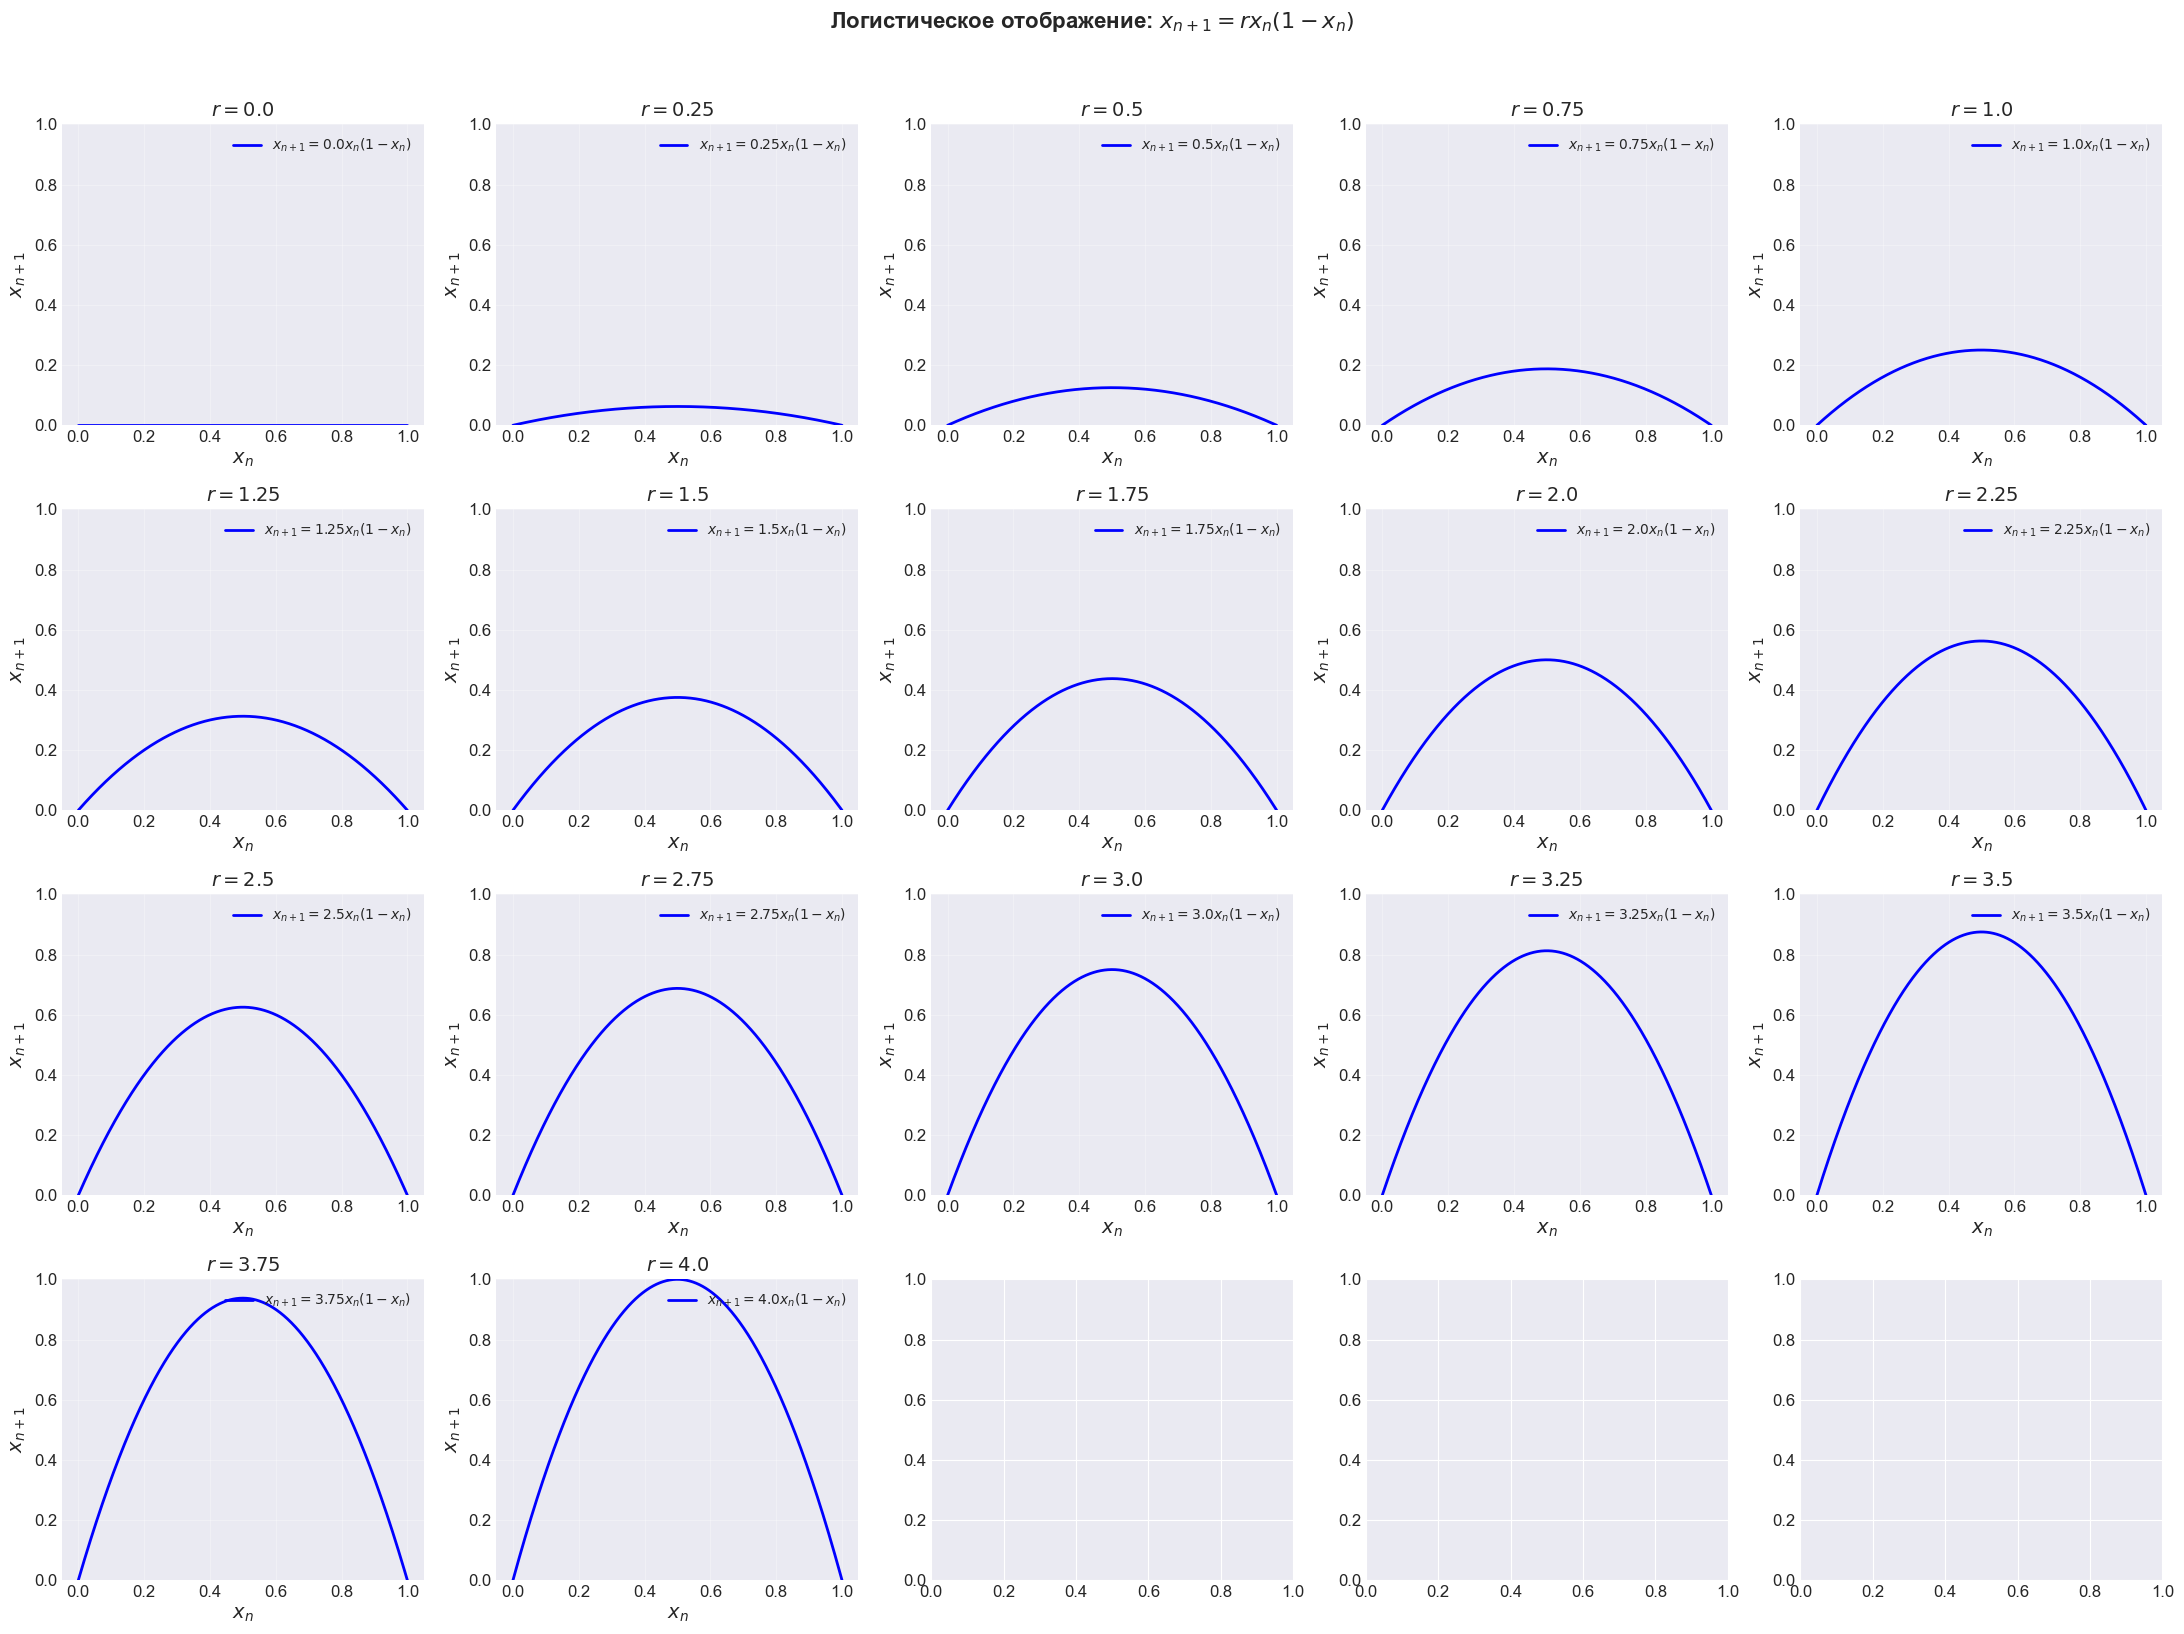

In [4]:
x0_values = np.arange(0, 1.1, 0.1)
r_values = np.arange(0, 4.25, 0.25)  # 17

len_r_values = len(r_values)

fig, axes = plt.subplots(4, 5, figsize=(22, 16))

for idx, (r, ax) in enumerate(zip(r_values, axes.flatten())):
    # Значение x от 0 до 1 с шагом 1000
    x = np.linspace(0, 1, 1000)

    # Считаем для каждого x_n x_{n+1}
    x_next = f(x, r)

    # Рисуем функцию перехода
    ax.plot(x, x_next, 'b-', linewidth=2, label=f'$x_{{n+1}} = {r}x_n(1-x_n)$')

    ax.set_ylim(0, 1)
    ax.set_xlabel('$x_n$', fontsize=14)
    ax.set_ylabel('$x_{n+1}$', fontsize=14)
    ax.set_title(f'$r = {r}$', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax.legend(loc='upper right', fontsize=10)

plt.suptitle(f.__doc__, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

$f(x) = rx(1 - x) = r(-x^2 + x) = r(-(x-\frac{1}{2})^2 + \frac{1}{4})$ - парабола с ветвями вниз c $x_0 = 0.5$ и $y_0 = \frac{r}{4}$

Параметр $r$ растягивает $f$ по оси $Y$, увеличивая её максимальное значение.

---

$N = {ISU} \mod 5 = 501679 \mod 5 = 4$ - вариант лабораторной работы.
$$g(x_{n+1}) = rx_n(1 - x_n)(2 - x_n), r \in (0, \frac{3\sqrt3}{2}], x \in [0, 1]$$

##### Easy:
Для заданной вариантом функции $g(x_n)$:
1. Постройте графики зависимости $x_n$ от $x_{n−1}$ для нескольких различных значений r.
2. Сделайте вывод о сходстве или различии поведения логистического отображения и точечного отображения. Предположите: чем могут быть вызваны сходства/различия?

---

In [5]:
def g(x, r):
    """Точечное отображение: $g(x_{n+1}) = rx_n(1 - x_n)(2 - x_n)$"""
    return r * x * (1 - x) * (2 - x)

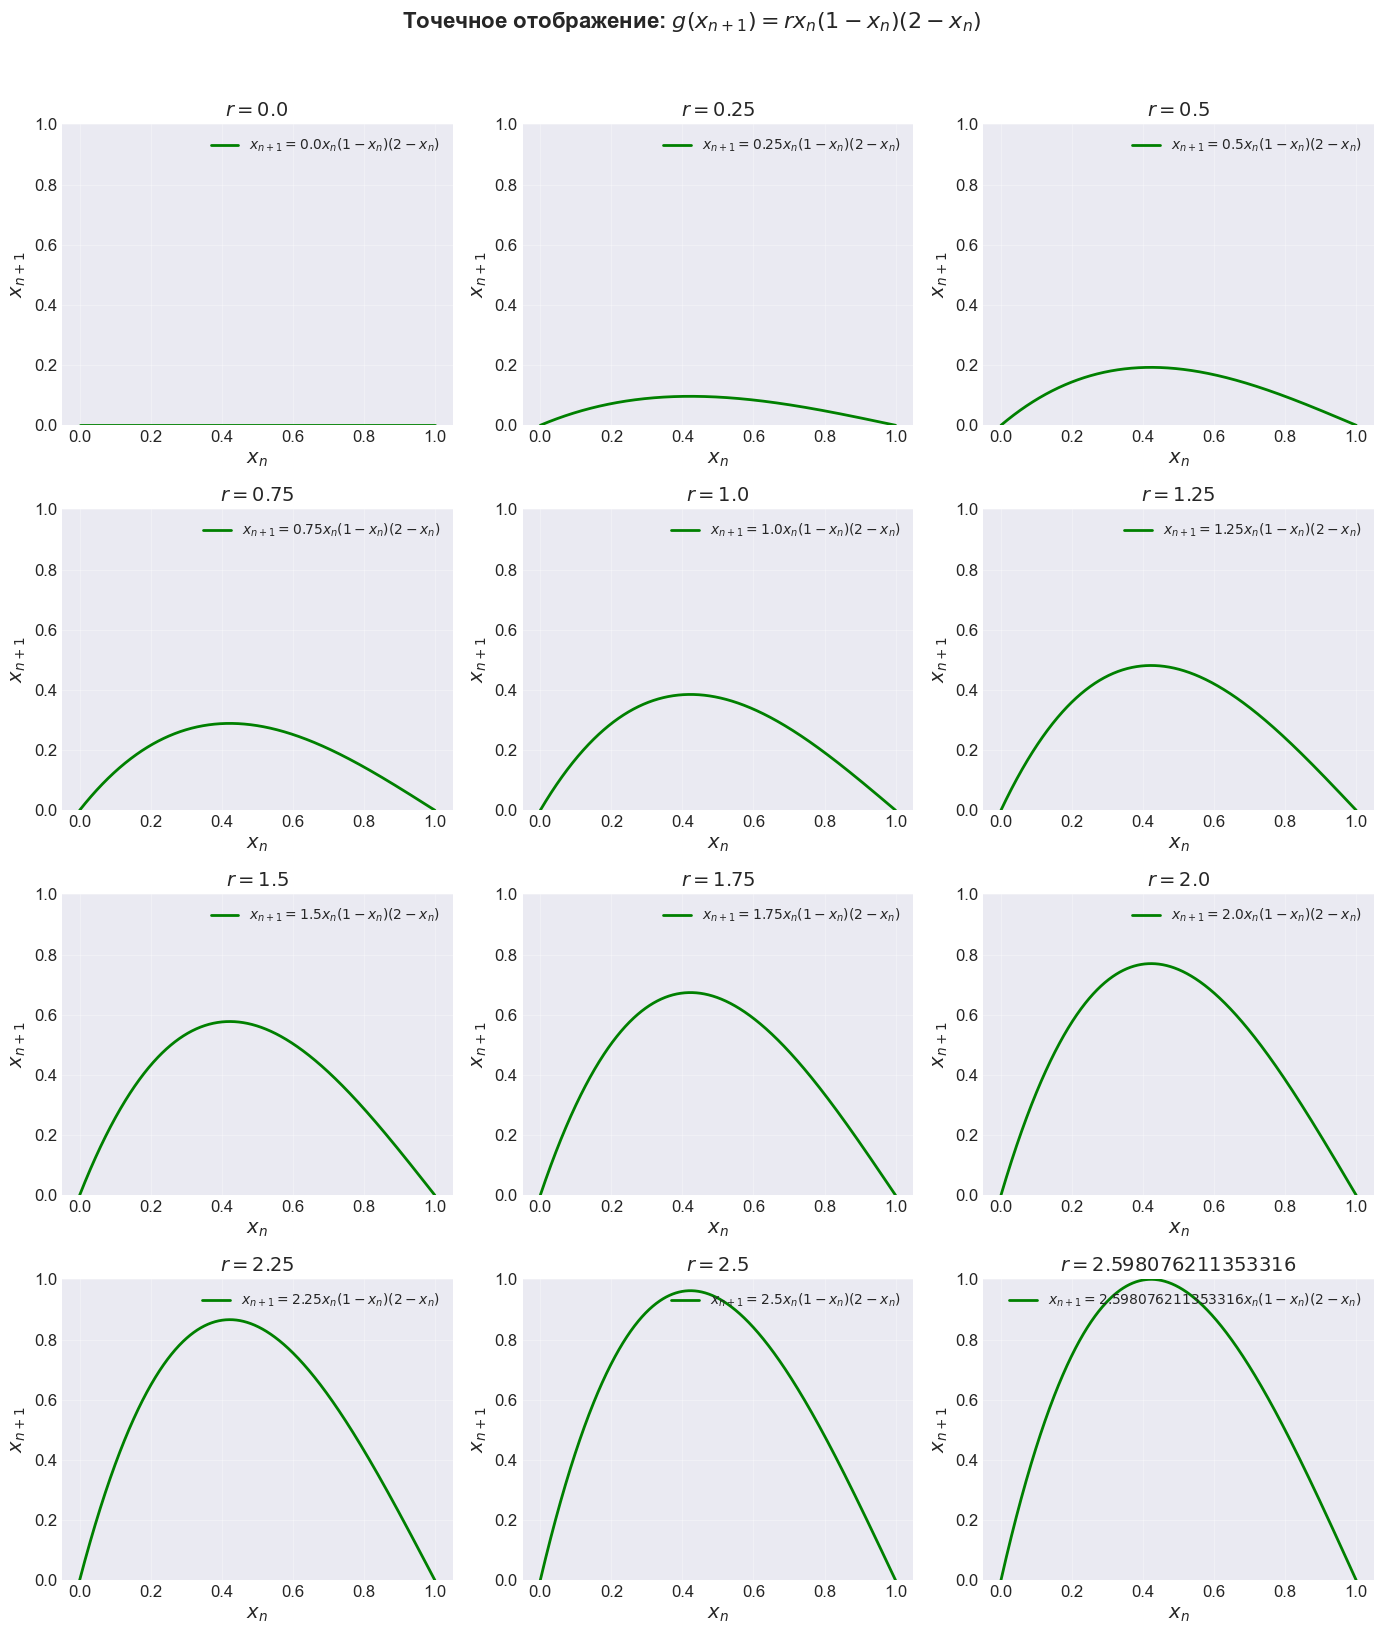

In [6]:
from math import sqrt


r_limit = 3 * sqrt(3) / 2

x0_values = np.arange(0, 1.1, 0.1)
r_values = np.arange(0, r_limit, 0.25)
r_values = np.append(r_values, r_limit)  # 12

len_r_values = len(r_values)

fig, axes = plt.subplots(4, 3, figsize=(14, 16))

for idx, (r, ax) in enumerate(zip(r_values, axes.flatten())):
    # Значение x от 0 до 1 с шагом 1000
    x = np.linspace(0, 1, 1000)

    # Считаем для каждого x_n x_{n+1}
    x_next = g(x, r)

    # Рисуем функцию перехода
    ax.plot(x, x_next, 'g-', linewidth=2, label=f'$x_{{n+1}} = {r}x_n(1-x_n)(2-x_n)$')

    ax.set_ylim(0, 1)
    ax.set_xlabel('$x_n$', fontsize=14)
    ax.set_ylabel('$x_{n+1}$', fontsize=14)
    ax.set_title(f'$r = {r}$', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax.legend(loc='upper right', fontsize=10)

plt.suptitle(g.__doc__, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

$$g(x) = rx(1 - x)(2 - x) = rx(x - 1)(x - 2) = rx(x^2 - 3x + 2) = r(x^3 - 3x^2 + 2x) \text{ — степенная функция с показателем степени 3}$$

Графики $f(x_n)$ и $g(f_n)$ довольно схожи, так как
* $g(x) = f(x)(2 - x)$, при $1 < 2 - x < 2 \Longleftrightarrow f(x) < g(x) < 2f(x)$,
* обе являются степенными функциями.

---

# Normal

**Неподвижная точка** $x^*$ переходит сама в себя под действием отображения, то есть удовлетворяет соотношению
$$x^* = f(x∗)$$

#### Normal:
1. Найдите все неподвижные точки логистического отображения.
2. При каких r отображение имеет одну неподвижную точку? Несколько?
3. Какое максимальное количество неподвижных точек может иметь логистическое отображение? Почему?

---

##### 1. Все неподвижные точки логистического отображения

Рассмотрим $x = 0$
$$f(x) = 0 \Longrightarrow \forall r:  x = 0 \text{ — неподвижная точка}$$

Рассмотрим $x \neq 0$. Пусть $x^*$ — неподвижная точка.
$$f(x^*) = rx^*(1 - x^*) = x^* \Longrightarrow x^* = 1 - \frac{1}{r}$$
$$\begin{cases}
x \in [0, 1] \\
x^* = 1 - \frac{1}{r} \\
\end{cases} \Longrightarrow \exists x^* = 1 - \frac{1}{r}, \text{ только при } r \geq 1$$

$$x =
\begin{cases}
0 \\
1 - \frac{1}{r}, r \geq 1 \\
\end{cases} \text{ — неподвижные точки}$$

##### 2. Количество неподвижный точек от $r$

Как было показано выше, количество неподвижных точек при
* $r \in [0, 1)$: одна неподвижная точка $x = 0$,
* $r \in (1, 4]$: две неподвижные точки $x = 0$ и $x = 1 - \frac{1}{r}$.

##### 3. Максимальное количество неподвижных точек

Так как $f(x)$ - парабола и система
$$\begin{cases}
f(x) = x \\
f(x) = rx(1 - x) \\
\end{cases}$$
может иметь максимум 2 решение, максимальное количество неподвижный точек тоже 2.

Для логического отображения $f(x)$ и параметров $x \in [0, 1]$ и $r \in [0, 4]$ количество неподвижных точек 1, либо 2.

---

#### Normal:
Докажите, что при $x_0 \in (0; 1)$ и $r \in (0; 1]$ последовательность $\{x_n\}$, заданная логистическим отображением, монотонно убывает. Существует ли предел у данной последовательности при $r \in (0; 1]$? Докажите. Покажите графически.

---

Из ранее доказанного имеем, что $\forall n \in \mathbb{N}$ выполняется $0 < x_n < 1$.

Сравним $x_n$ и $x_{n+1}$:
$$
0 < x_n < 1 \Longleftrightarrow 0 < 1 - x_n < 1
$$

$$
x_{n+1} = r \cdot x_n(1 - x_n) \leq x_n \cdot (1 - x_n) < x_n
$$

Таким образом, $\forall r \in (0; 1]$ и $\forall n \in \mathbb{N}$ выполняется:
$$
x_{n+1} < x_n
$$

Это означает, что последовательность $\{x_n\}$ **строго монотонно убывает**.

Последовательность $\{x_n\}$ обладает следующими свойствами:
1. **Монотонность:** Последовательность строго монотонно убывает (доказано выше).
2. **Ограниченность снизу:** $\forall n \in \mathbb{N} : x_n > 0$, поэтому последовательность ограничена снизу числом $0$.

Согласно теореме Вейерштрасса о пределе монотонной ограниченной последовательности, существует конечный предел:
$$
\lim_{n \to \infty} x_n = a
$$

Таким образом у последовательности $\{x_n\}$, при при $x_0 \in (0; 1)$ и $r \in (0; 1]$, существует предел. $\blacksquare$

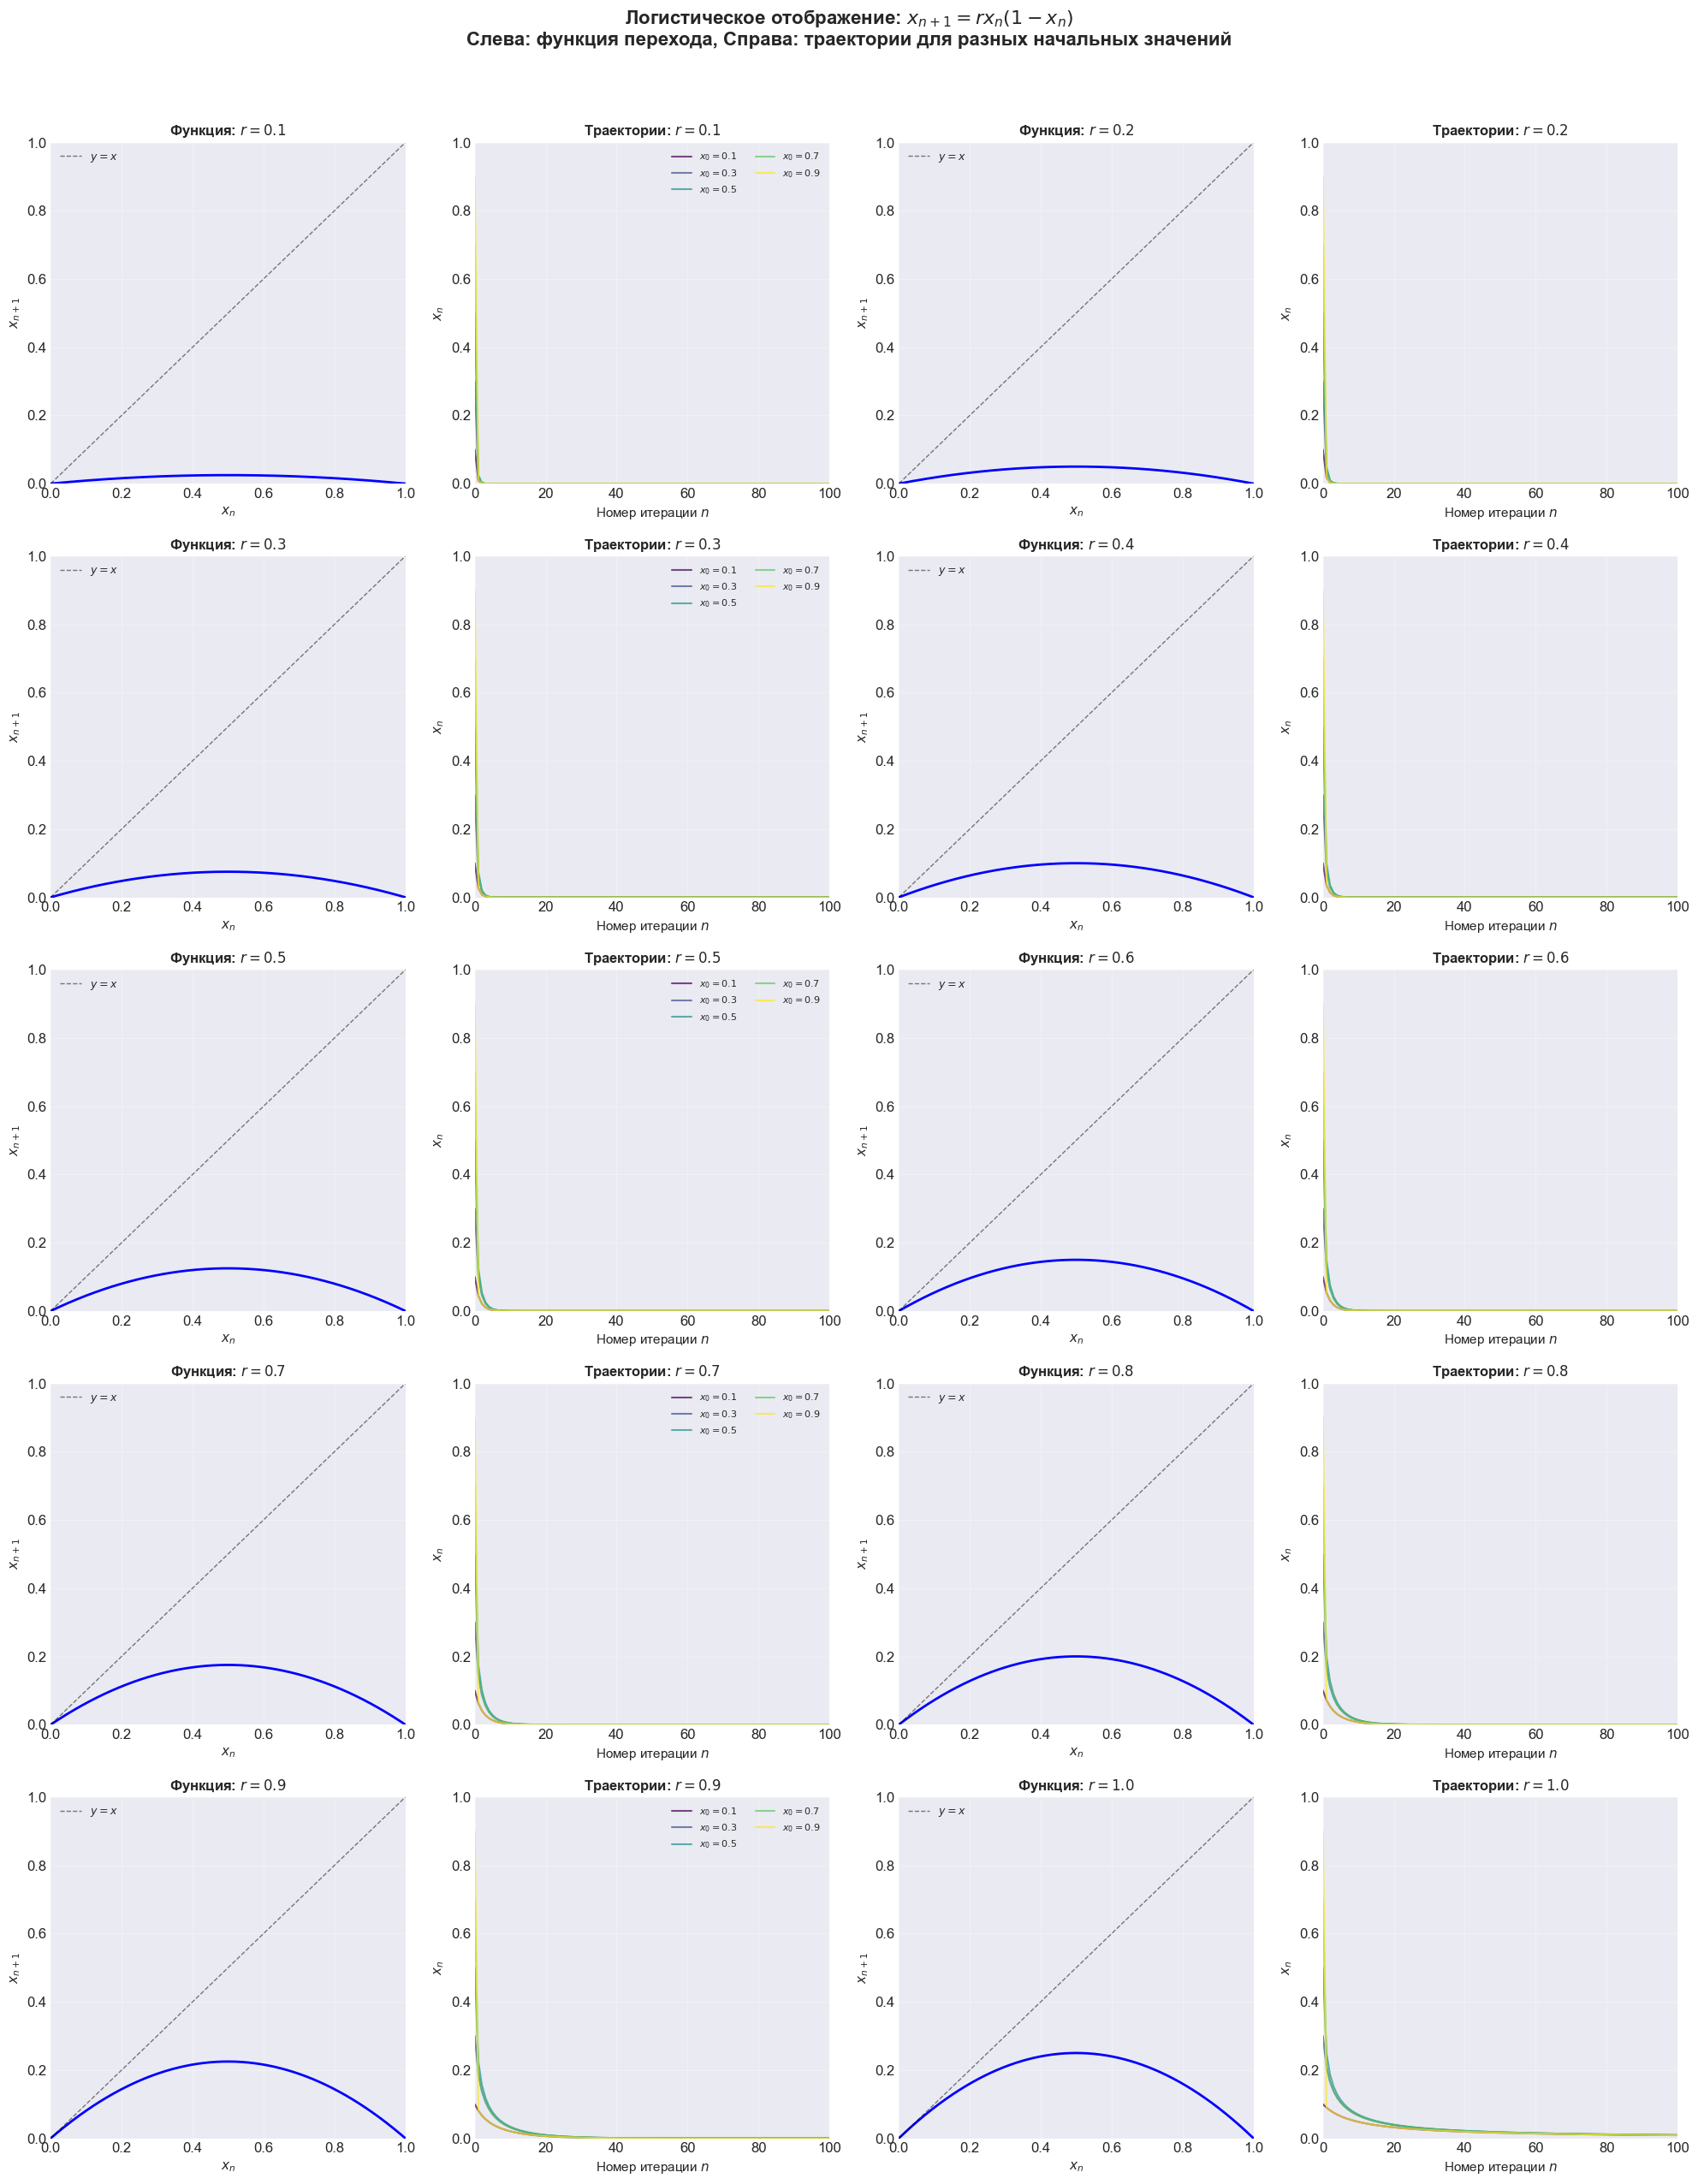

In [7]:
# Параметры
x0_values = np.arange(0.1, 1, 0.2)
r_values = np.arange(0.1, 1.1, 0.1)
colors = plt.cm.viridis(np.linspace(0, 1, len(x0_values)))
n_iterations = 100

# Вычисляем количество строк и столбцов
rows = (len(r_values) + 1) // 2
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))

# Преобразуем axes в плоский массив
if rows == 1:
    axes = axes.reshape(1, -1)

# Проходим по всем значениям r
for idx, r in enumerate(r_values):
    row = idx // 2  # Каждые 2 значения r на одной строке
    col_offset = (idx % 2) * 2  # 0 или 2

    # ===== ЛЕВЫЙ ГРАФИК: Функция перехода =====
    ax_left = axes[row, col_offset]

    # Значение x от 0 до 1
    x = np.linspace(0, 1, 1000)
    x_next = f(x, r)

    # Рисуем функцию перехода
    ax_left.plot(x, x_next, 'b-', linewidth=2)
    ax_left.plot(x, x, 'k--', alpha=0.5, linewidth=1, label='$y = x$')

    # Отмечаем неподвижные точки
    if r > 1:
        x_star = 1 - 1 / r
        ax_left.plot(x_star, x_star, 'ro', markersize=6, label='Неподвижные точки')

    # Настройки левого графика
    ax_left.set_xlim(0, 1)
    ax_left.set_ylim(0, 1)
    ax_left.set_xlabel('$x_n$', fontsize=11)
    ax_left.set_ylabel('$x_{n+1}$', fontsize=11)
    ax_left.set_title(f'Функция: $r = {r:.1f}$', fontsize=12, fontweight='bold')
    ax_left.grid(True, alpha=0.3)
    ax_left.legend(loc='upper left', fontsize=9)

    # ===== ПРАВЫЙ ГРАФИК: Траектории для разных x_0 =====
    ax_right = axes[row, col_offset + 1]

    # Строим траектории
    for x0_idx, x0 in enumerate(x0_values):
        # Генерируем траекторию
        trajectory = [x0]
        for i in range(n_iterations):
            next_val = f(trajectory[-1], r)
            trajectory.append(next_val)

        # Рисуем траекторию
        ax_right.plot(range(n_iterations + 1), trajectory,
                      color=colors[x0_idx],
                      alpha=0.7,
                      linewidth=1.5)

    # Настройки правого графика
    ax_right.set_xlabel('Номер итерации $n$', fontsize=11)
    ax_right.set_ylabel('$x_n$', fontsize=11)
    ax_right.set_title(f'Траектории: $r = {r:.1f}$', fontsize=12, fontweight='bold')
    ax_right.set_xlim(0, n_iterations)
    ax_right.set_ylim(0, 1)
    ax_right.grid(True, alpha=0.3)

    # Добавляем легенду для начальных значений
    if col_offset == 0:  # Только для первого столбца в каждой строке
        legend_labels = [f'$x_0 = {x0:.1f}$' for x0 in x0_values]
        ax_right.legend(legend_labels, loc='upper right', fontsize=8, ncol=2)

# Скрываем пустые subplots (если количество r нечетное)
for idx in range(len(r_values), rows * 2):
    row = idx // 2
    col_offset = (idx % 2) * 2
    axes[row, col_offset].axis('off')
    axes[row, col_offset + 1].axis('off')

plt.suptitle('Логистическое отображение: $x_{n+1} = rx_n(1 - x_n)$\n'
             'Слева: функция перехода, Справа: траектории для разных начальных значений',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

#### Normal:
Пусть $r \in (2; 3), x_{2n} > x^∗, x_{2n+1} <x^∗$. Что вы можете сказать о монотонности подпоследовательностей $\{x_{2n}\}, \{x_{2n+1}\}$? Докажите. Проверьте графически.

---

**Вторая итерация**: $f^2(x) = f(f(x))$.

Рассмотрим функцию:
$$
h(x) = f^2(x) - x.
$$

**Известные корни $g(x)$:**
- $h(0) = 0$ (так как $f(0) = 0$, $f^2(0) = 0$)
- $h(x^*) = 0$ (так как $f(x^*) = x^*$, $f^2(x^*) = x^*$)

**Проверим знак вблизи границ:**

1. **Малые $x > 0$:**
   $$
   f(x) \approx r x, \quad f^2(x) \approx r^2 x
   $$
   Так как $r > 1$, то $r^2 > 1$, следовательно:
   $$
   f^2(x) > x \quad \text{для малых } x > 0.
   $$

2. **Значения вблизи $x = 1$:**
   $$
   f(1) = 0, \quad f^2(1) = f(0) = 0
   $$
   $$
   g(1) = 0 - 1 = -1 < 0
   $$
   Следовательно, $f^2(x) < x$ для $x$, близких к 1.

**Поскольку:**
- $h(x)$ непрерывна на $[0; 1]$
- $h(x)$ имеет только корни $0$ и $x^*$
- $h(x) > 0$ при малых $x > 0$
- $h(x) < 0$ при $x$, близких к 1

Тогда:
- На интервале $(0; x^*)$ функция $h(x)$ не меняет знак и $g(x) > 0$
- На интервале $(x^*; 1)$ функция $h(x)$ не меняет знак и $g(x) < 0$

Следовательно:
$$
\begin{cases}
f^2(x) > x, & x \in (0; x^*) \\
f^2(x) < x, & x \in (x^*; 1)
\end{cases}
$$

**Для чётных членов**:
$$
x_{2n} > x^* \quad \Rightarrow \quad f^2(x_{2n}) < x_{2n}
$$
$$
x_{2(n+1)} = f^2(x_{2n}) < x_{2n}
$$
Подпоследовательность $\{x_{2n}\}$ **строго монотонно убывает**.

**Для нечётных членов**:
$$
x_{2n+1} < x^* \quad \Rightarrow \quad f^2(x_{2n+1}) > x_{2n+1}
$$
$$
x_{2(n+1)+1} = f^2(x_{2n+1}) > x_{2n+1}
$$
Подпоследовательность $\{x_{2n+1}\}$ **строго монотонно возрастает**.

Обе подпоследовательности ограничены:
- $\{x_{2n}\}$ ограничена снизу $x^*$
- $\{x_{2n+1}\}$ ограничена сверху $x^*$

По теореме о пределе монотонной ограниченной последовательности существуют пределы:
$$
\lim_{n \to \infty} x_{2n} = L_1, \quad \lim_{n \to \infty} x_{2n+1} = L_2.
$$

Переходя к пределу в равенствах:
$$
x_{2(n+1)} = f^2(x_{2n}), \quad x_{2(n+1)+1} = f^2(x_{2n+1}),
$$
получаем:
$$
L_1 = f^2(L_1), \quad L_2 = f^2(L_2).
$$

Единственными решениями $f^2(x) = x$ в соответствующих интервалах являются:
- $L_1 \in [x^*; 1]$: решение $L_1 = x^*$
- $L_2 \in (0; x^*]$: решение $L_2 = x^*$

Следовательно:
$$
\lim_{n \to \infty} x_{2n} = \lim_{n \to \infty} x_{2n+1} = x^*.
$$

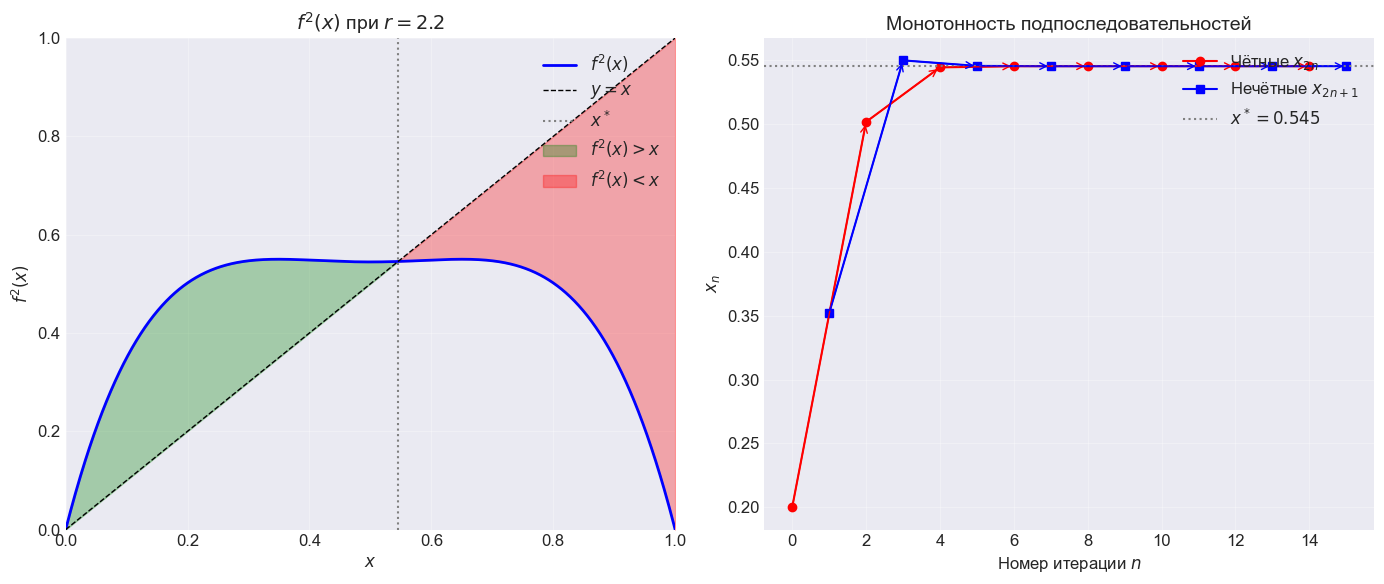

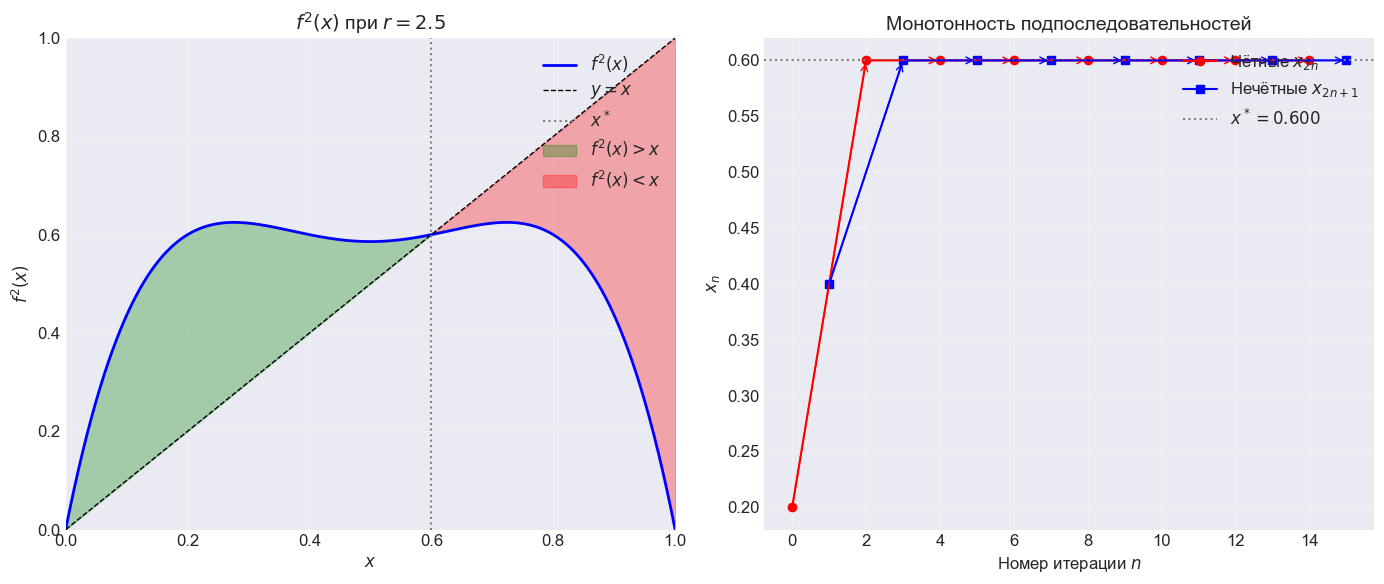

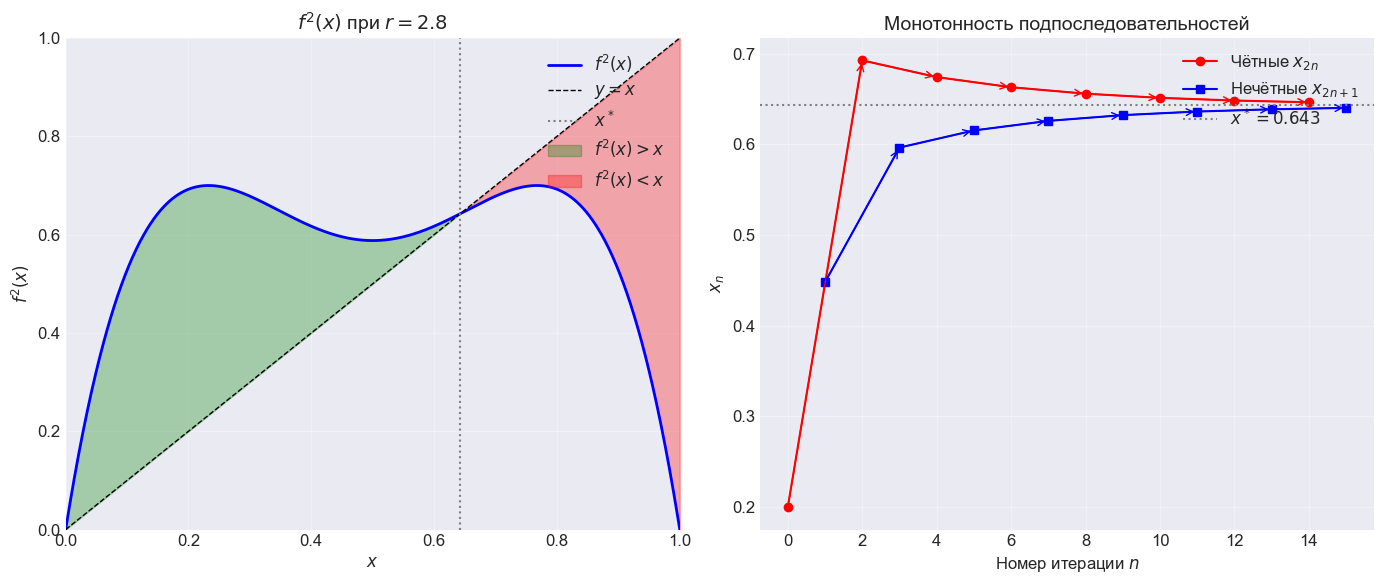

In [8]:
def plot_monotonicity(r=2.5, x0=0.2, n_iter=20):
    """Визуализация монотонности подпоследовательностей"""
    # Неподвижная точка
    x_star = 1 - 1 / r

    # Генерируем последовательность
    x_vals = [x0]
    for i in range(n_iter):
        x_vals.append(f(x_vals[-1], r))

    # Разделяем чётные и нечётные
    even_idx = list(range(0, len(x_vals), 2))
    odd_idx = list(range(1, len(x_vals), 2))
    x_even = [x_vals[i] for i in even_idx]
    x_odd = [x_vals[i] for i in odd_idx]

    # График f^2(x)
    x_range = np.linspace(0, 1, 1000)
    f1 = f(x_range, r)
    f2 = f(f1, r)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Левый график: f^2(x) и диагональ
    ax1.plot(x_range, f2, 'b-', linewidth=2, label=r'$f^2(x)$')
    ax1.plot(x_range, x_range, 'k--', linewidth=1, label='$y = x$')
    ax1.axvline(x_star, color='gray', linestyle=':', label='$x^*$')

    # Заливка областей
    mask1 = x_range < x_star
    mask2 = x_range > x_star
    ax1.fill_between(x_range[mask1], f2[mask1], x_range[mask1],
                     where=f2[mask1] > x_range[mask1],
                     color='green', alpha=0.3, label='$f^2(x) > x$')
    ax1.fill_between(x_range[mask2], f2[mask2], x_range[mask2],
                     where=f2[mask2] < x_range[mask2],
                     color='red', alpha=0.3, label='$f^2(x) < x$')

    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel('$x$', fontsize=12)
    ax1.set_ylabel('$f^2(x)$', fontsize=12)
    ax1.set_title(f'$f^2(x)$ при $r = {r}$', fontsize=14)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Правый график: итерации
    ax2.plot(even_idx, x_even, 'ro-', markersize=6, linewidth=1.5,
             label='Чётные $x_{2n}$')
    ax2.plot(odd_idx, x_odd, 'bs-', markersize=6, linewidth=1.5,
             label='Нечётные $x_{2n+1}$')
    ax2.axhline(x_star, color='gray', linestyle=':', linewidth=1.5,
                label=f'$x^* = {x_star:.3f}$')

    # Добавляем стрелки для наглядности
    for i in range(len(even_idx)-1):
        ax2.annotate('', xy=(even_idx[i+1], x_even[i+1]),
                     xytext=(even_idx[i], x_even[i]),
                     arrowprops=dict(arrowstyle='->', color='red', lw=1))
    for i in range(len(odd_idx)-1):
        ax2.annotate('', xy=(odd_idx[i+1], x_odd[i+1]),
                     xytext=(odd_idx[i], x_odd[i]),
                     arrowprops=dict(arrowstyle='->', color='blue', lw=1))

    ax2.set_xlabel('Номер итерации $n$', fontsize=12)
    ax2.set_ylabel('$x_n$', fontsize=12)
    ax2.set_title('Монотонность подпоследовательностей', fontsize=14)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

for r in [2.2, 2.5, 2.8]:
    plot_monotonicity(r=r, x0=0.2, n_iter=15)

При $r \in (2; 3)$ и условиях $x_{2n} > x^*$, $x_{2n+1} < x^*$:
1. Подпоследовательность $\{x_{2n}\}$ **строго монотонно убывает**.
2. Подпоследовательность $\{x_{2n+1}\}$ **строго монотонно возрастает**.
3. Обе подпоследовательности сходятся к неподвижной точке $x^*$, поэтому вся последовательность $\{x_n\}$ также сходится к $x^*$.

---

#### Normal:
Для отображения $g(x_n)$, заданного вариантом:
1. Аналитически найдите неподвижную точку.
2. Найдите или оцените диапазон параметра r, при котором последовательность монотонно сходится к нулю.
3. Постройте графики зависимости $x_n$ от $n$ для нескольких различных значений параметра $r$.

---

**Неподвижная точка** удовлетворяет условию:
$$
g(x) = x
$$

$$
g(x) = rx(1 - x)(2 - x) = x
$$


**Рассмотрим** $x = 0$:

$$g(0) = 0 \text{ — удовлетворяет условию неподвижной точки}$$

Таким образом, $x = 0$ — неподвижная точка.
**Рассмотрим** $x \neq 0$:
$$
r (1 - x)(2 - x) = 1
$$

$$
rx(1 - x)(2 - x) = x \Longleftrightarrow r(x^2 - 3x + 2) = 1 \Longleftrightarrow r x^2 - 3r x + 2r - 1 = 0
$$
$$
D = (-3r)^2 - 4 \cdot r \cdot (2r - 1) = 9r^2 - 8r^2 + 4r = r^2 + 4r
$$

$$
\begin{cases}
x_1 = \frac{3r + \sqrt{r^2 + 4r}}{2r} \\
x_2 = \frac{3r - \sqrt{r^2 + 4r}}{2r} \\
\end{cases}
$$
Нужно проверить, что корни попадают в промежуток (0; 1).

**Рассмотрим** $x_1$:

$$
\sqrt{r^2 + 4r} > r \text{ при } r > 0 \Longrightarrow x_1 = \frac{3r + \sqrt{r^2 + 4r}}{2r} > \frac{3r + r}{2r} = \frac{4r}{2r} = 2
$$

$$\text{Но } x \in (0; 1) \text{ - противоречие}$$

**Рассмотрим** $x_2$:

$$
x_2 = \frac{3r - \sqrt{r^2 + 4r}}{2r} > 0 \Longleftrightarrow 3r - \sqrt{r^2 + 4r} > 0 \Longleftrightarrow 9r^2 > r^2 + 4r \Longleftrightarrow 8r^2 > 4r \Longleftrightarrow 2r > 1 \Longleftrightarrow r > \frac{1}{2}
$$

$$
x_2 = \frac{3r - \sqrt{r^2 + 4r}}{2r} < 1 \Longleftrightarrow 3r - \sqrt{r^2 + 4r} < 2r \Longleftrightarrow r < \sqrt{r^2 + 4r}
$$

$$
r < \sqrt{r^2} < \sqrt{r^2 + 4r} \Longrightarrow \forall r > 0 : r < \sqrt{r^2 + 4r}
$$
Таким образом, при
* $r > 0$: существует неподвижная точка $x = 0$.

* $r > \frac{1}{2}$: появляется вторая неподвижная точка:
   $$
   x^* = \frac{3r - \sqrt{r^2 + 4r}}{2r}
   $$

**Условие монотонной сходимости** к $0$:
$$
0 < g(x) < x \quad \forall x \in (0,1)
$$
При $x > 0$:
$$
g(x) < x \ \Longleftrightarrow \ r(1-x)(2-x) < 1
$$

Рассмотрим $h(x) = r(1-x)(2-x)$:
$$
\max_{x \in [0,1]} h(x) = h(0) = 2r
$$
$$
2r < 1 \ \Longleftrightarrow \ r < \frac{1}{2}
$$

При $r = \frac{1}{2}$:
$$
g(x) \leq x \quad \forall x \in [0,1]
$$

**Устойчивость точки** $x = 0$:
$$
g'(x) = r(2 - 6x + 3x^2)
$$
$$
g'(0) = 2r
$$
$$
|g'(0)| < 1 \ \Longleftrightarrow \ 2r < 1 \ \Longleftrightarrow \ r < \frac{1}{2}
$$

Таким образом, монотонная сходимость к $0$ наблюдается при:
$$
0 < r \leq \frac{1}{2}
$$

<>:71: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:71: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/var/folders/9g/5h0d1k6d34352hd0w8nzpxxc0000gn/T/ipykernel_3590/3493018847.py:71: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  'для $x_0 \in \{0, 0.25, 0.5, 0.75, 1\}$',


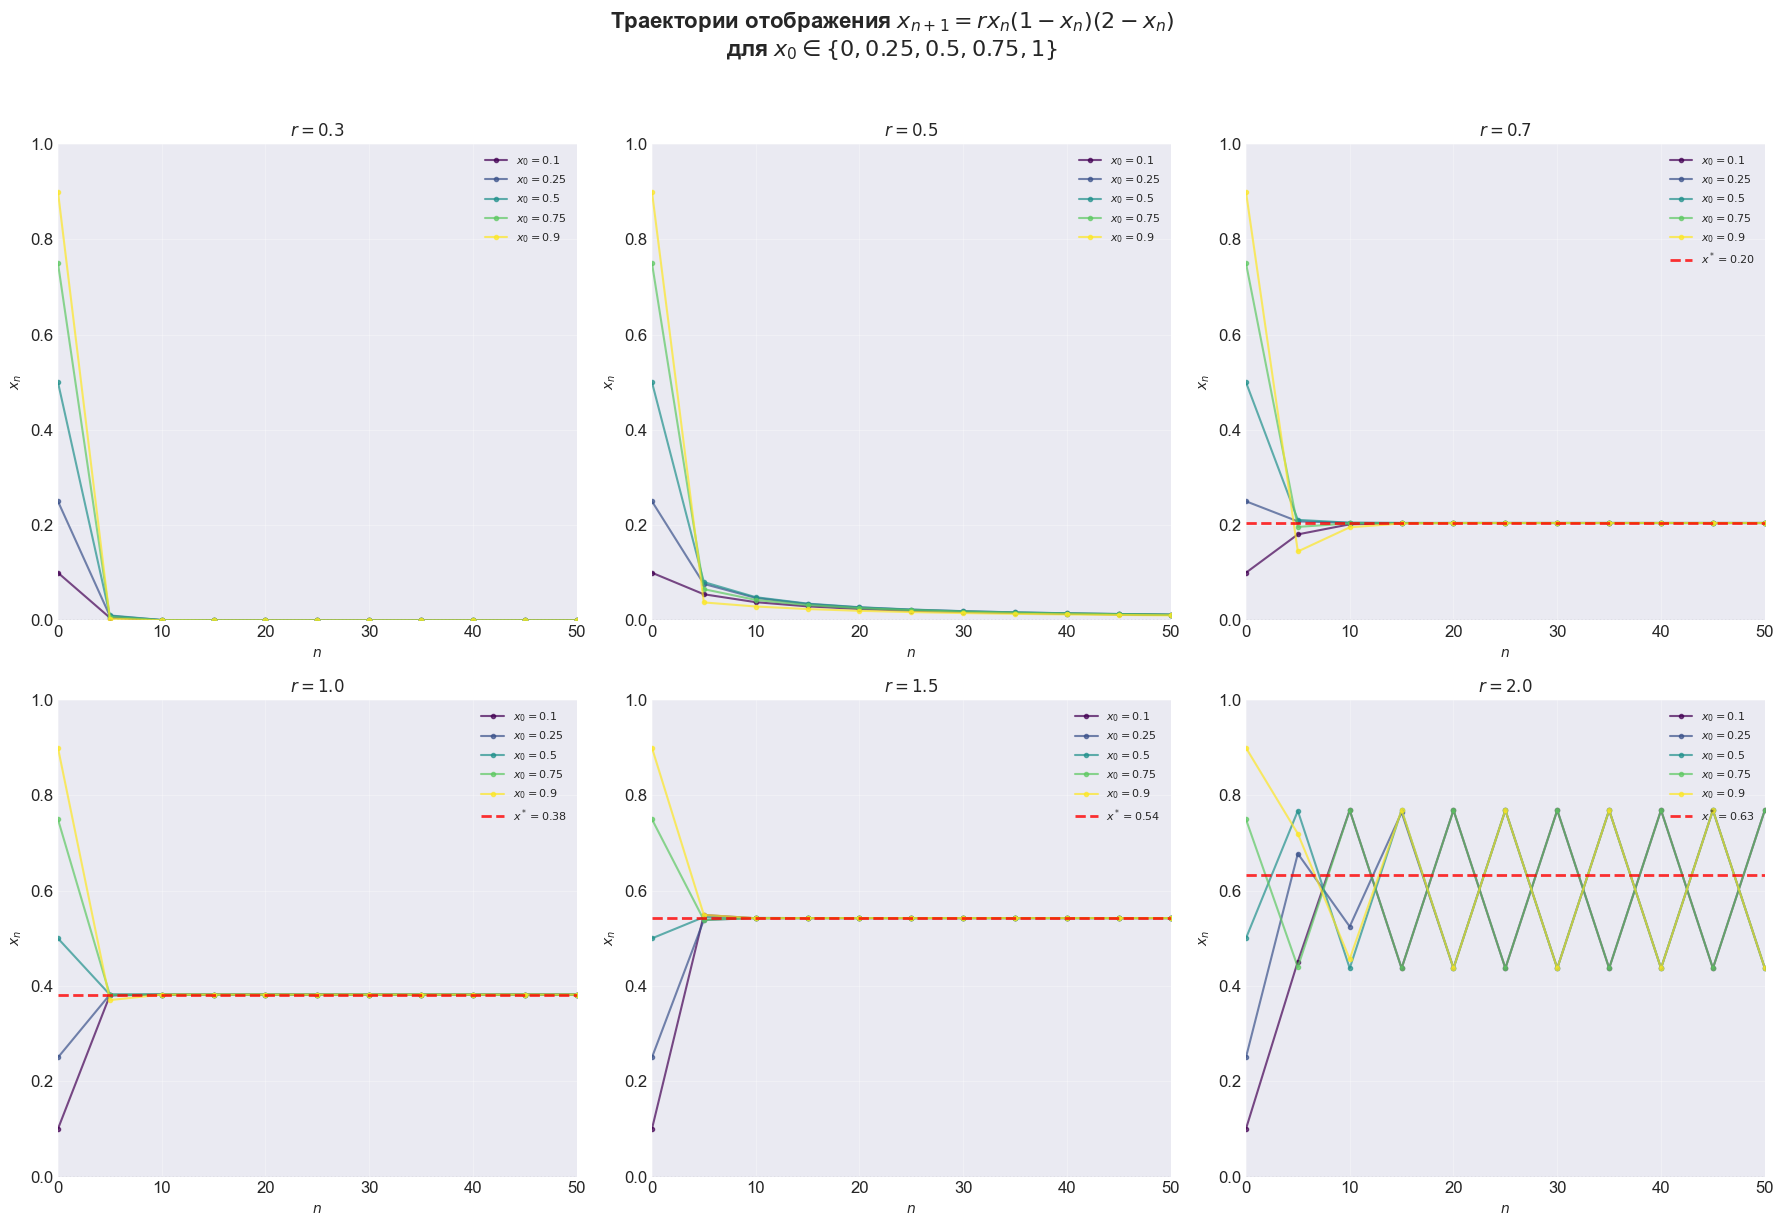

In [9]:
# Параметры
x0_values = [0.1, 0.25, 0.5, 0.75, 0.9]
n_iter = 50

# Различные значения параметра r
r_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

# Построение графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i in range(2):
    for j in range(3):
        idx = i * 3 + j
        if idx >= len(r_values):
            axes[i, j].axis('off')
            continue

        r = r_values[idx]
        ax = axes[i, j]

        # Цвета для текущего графика
        colors = plt.cm.viridis(np.linspace(0, 1, len(x0_values)))

        # Для каждого начального значения строим траекторию
        for x0_idx, x0 in enumerate(x0_values):
            x_sequence = [x0]

            for k in range(n_iter):
                x_sequence.append(g(x_sequence[-1], r))

            # Упрощаем отображение для больших n_iter
            if n_iter > 30:
                # Показываем каждую 5-ю точку
                indices = range(0, n_iter + 1, 5)
                reduced_seq = [x_sequence[i] for i in indices]
                ax.plot(indices, reduced_seq, 'o-',
                        color=colors[x0_idx],
                        markersize=3,
                        linewidth=1.5,
                        alpha=0.7,
                        label=f'$x_0={x0}$')
            else:
                ax.plot(range(n_iter + 1), x_sequence, 'o-',
                        color=colors[x0_idx],
                        markersize=4,
                        linewidth=1.5,
                        alpha=0.7,
                        label=f'$x_0={x0}$')

        # Настройки графика
        ax.set_xlabel('$n$', fontsize=10)
        ax.set_ylabel('$x_n$', fontsize=10)
        ax.set_title(f'$r = {r}$', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, n_iter)
        ax.set_ylim(0, 1)

        # Отмечаем неподвижные точки
        if r > 0.5:
            x_star = (3 * r - np.sqrt(r * (r + 4))) / (2 * r)
            if 0 <= x_star <= 1:
                ax.axhline(y=x_star, color='red', linestyle='--',
                           alpha=0.8, linewidth=2, label=f'$x^*={x_star:.2f}$')

        ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

        # Легенда для каждого графика
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

plt.suptitle('Траектории отображения $x_{n+1} = r x_n (1 - x_n)(2 - x_n)$\n'
             'для $x_0 \in \{0, 0.25, 0.5, 0.75, 1\}$',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Hard

Если, стартуя из точки $x_1^*$, в результате $m$-кратного выполнения отображения $f(x)$, получается та же самая точка $x_1^*$, говорят, что $x_1^*$ — неподвижная точка кратности $m$. Формально:

$$
x_1^* = \overbrace{f(f( \dots f(x_1^*) \dots ))}^{m \text{ раз}} = f^m(x_1^*)
$$

Тогда **циклом порядка** $m$ называют последовательность:

$$
x_2^* = f(x_1^*), \; x_3^* = f(x_2^*), \; \dots, \; x_{m + 1}^* = f(x_m^*) = x_1^* \quad \forall i, j \; x_i^x \neq x_j^*
$$

Каждая точка данной последовательности является неподвижной точкой кратности $m$.

---

#### Hard:

1. Положим $r_\infty \approx 3.5699456 \dots$. Как изменяется длина цикла при $r \in (3; r_\infty)$?
2. Для $r \in (3; r_\infty)$ экспериментально установите, какие ограничения (закономерности) действуют на m?

---

<>:42: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:43: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:42: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:43: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/var/folders/9g/5h0d1k6d34352hd0w8nzpxxc0000gn/T/ipykernel_3590/302129541.py:42: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.suptitle('Логистическое отображение $x_{n+1} = r x_n (1 - x_n)$ при $r \in (3; r_\infty)$\n'
/var/folders/9g/5h0d1k6d34352hd0w8nzpxxc0000gn/T/ipykerne

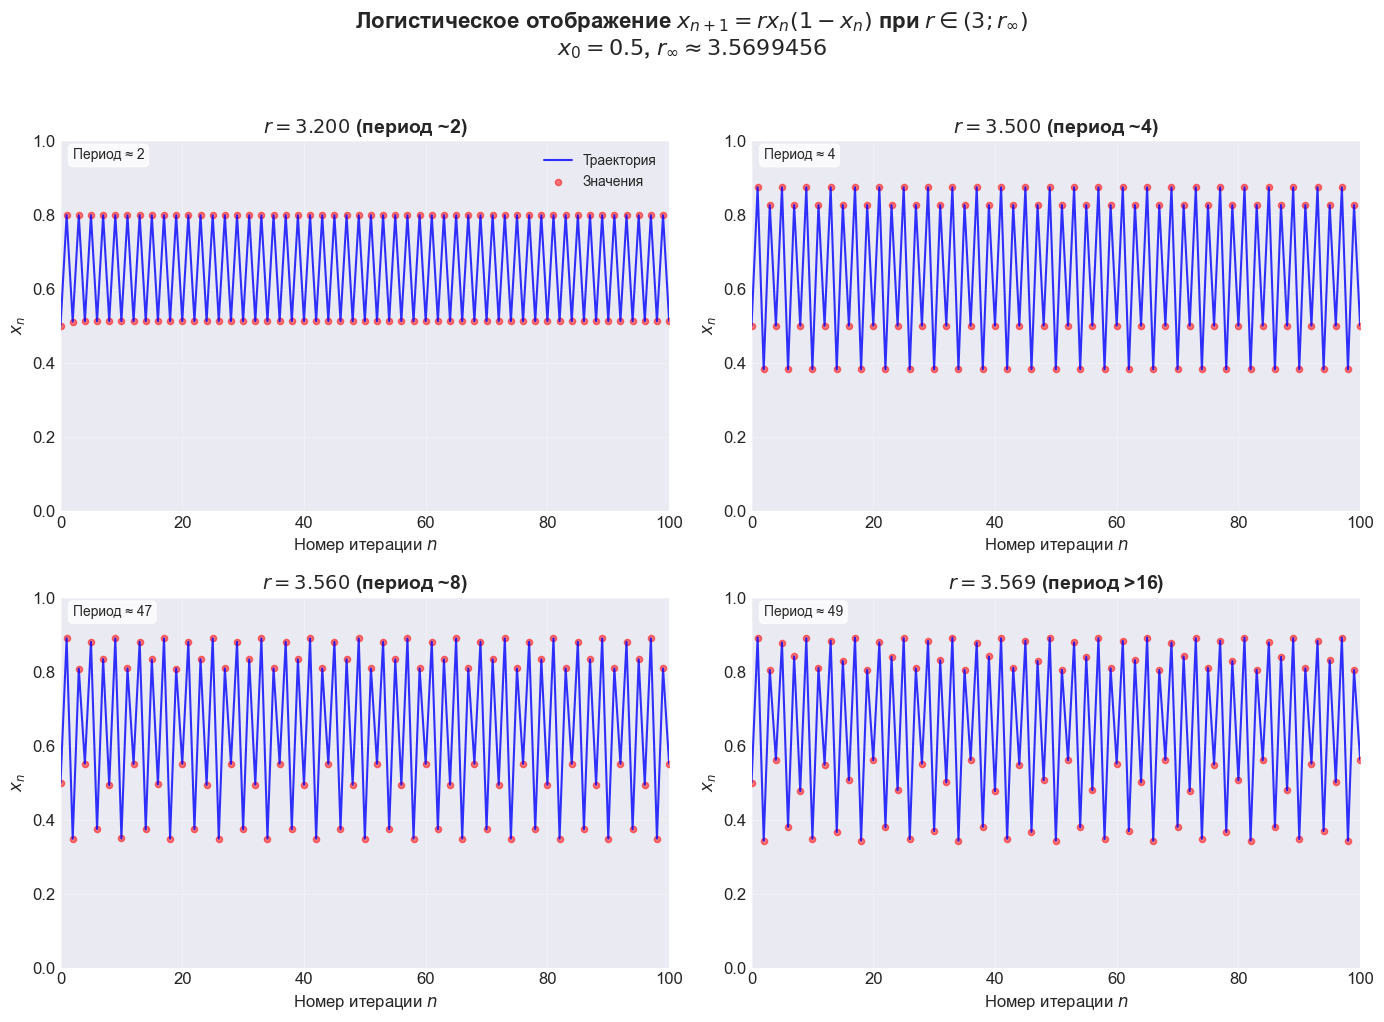

In [10]:
r_inf = 3.5699456
x0 = 0.5
n_iter = 100  # Количество итераций

# Характерные значения r из интервала (3, r_inf)
r_values = [3.2, 3.5, 3.56, 3.569]
periods = ['период ~2', 'период ~4', 'период ~8', 'период >16']

# Построение графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (r, period) in enumerate(zip(r_values, periods)):
    # Генерируем последовательность
    x_vals = [x0]
    for i in range(n_iter):
        x_vals.append(f(x_vals[-1], r))

    ax = axes[idx]
    ax.plot(range(n_iter + 1), x_vals, 'b-', linewidth=1.5, alpha=0.8, label='Траектория')
    ax.scatter(range(n_iter + 1), x_vals, s=20, color='red', alpha=0.5, label='Значения')

    # Настройки графика
    ax.set_xlabel('Номер итерации $n$', fontsize=12)
    ax.set_ylabel('$x_n$', fontsize=12)
    ax.set_title(f'$r = {r:.3f}$ ({period})', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, n_iter)
    ax.set_ylim(0, 1)

    # Подсчитываем количество уникальных значений (приблизительный период)
    # Используем округление для группировки близких значений
    unique_vals = np.unique(np.round(x_vals[-50:], 6))
    ax.text(0.02, 0.98, f'Период ≈ {len(unique_vals)}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Легенда только для первого графика
    if idx == 0:
        ax.legend(loc='upper right', fontsize=10)

plt.suptitle('Логистическое отображение $x_{n+1} = r x_n (1 - x_n)$ при $r \in (3; r_\infty)$\n'
             f'$x_0 = {x0}$, $r_\infty \\approx {r_inf}$',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Рассмотрим** логистическое отображение $x_{n+1} = r x_n (1 - x_n)$ при $r \in (3; r_\infty)$, где $r_\infty \approx 3.5699456\dots$

На графиках видно, что при $r \approx 3.2$ последовательность устанавливается на цикл из двух значений, при $r \approx 3.5$ — на цикл из четырёх значений, при $r \approx 3.56$ — на цикл из восьми значений, а при $r \approx 3.569$ период становится настолько большим, что на ограниченном числе итераций последовательность выглядит хаотической.

**Таким образом**, при увеличении $r$ в интервале $(3; r_\infty)$ происходит удвоение периода: длина цикла последовательно принимает значения $2, 4, 8, 16, 32, \dots$, то есть $m = 2^k$, где $k = 1, 2, 3, \dots$

В интервале $r \in (3; r_\infty)$ длина цикла $m$ может принимать только значения, являющиеся степенями двойки: $m = 2^k$, $k \in \mathbb{N}$. Это означает, что при данных $r$ невозможно наблюдать циклы других периодов (например, 3, 5, 6, 7, 9, ...).

---

#### Hard:
1. Напишите функцию, которая для заданного параметра r строит лестницу Ламерея.
2. Сделайте выводы: как выглядят циклы различных порядков на графике?

---

In [11]:
def lameere_ladder(f, x0, r, n_iter=20):
    """
    Строит лестницу Ламерея для отображения f(x, r)

    Параметры:
    f: функция отображения (f(x, r))
    x0: начальное значение
    r: параметр отображения
    n_iter: количество итераций

    Возвращает:
    x_points, y_points: координаты для построения лестницы
    """
    # Инициализируем массивы для хранения точек
    x_points = [x0]
    y_points = [0]

    # Текущие координаты
    x_curr = x0
    y_curr = 0

    for i in range(n_iter):
        # Вертикальный шаг: от (x_curr, y_curr) до (x_curr, f(x_curr, r))
        y_next = f(x_curr, r)
        x_points.append(x_curr)
        y_points.append(y_next)

        # Горизонтальный шаг: от (x_curr, y_next) до (y_next, y_next)
        x_next = y_next
        x_points.append(x_next)
        y_points.append(y_next)

        # Обновляем текущие координаты
        x_curr = x_next
        y_curr = y_next

    return np.array(x_points), np.array(y_points)

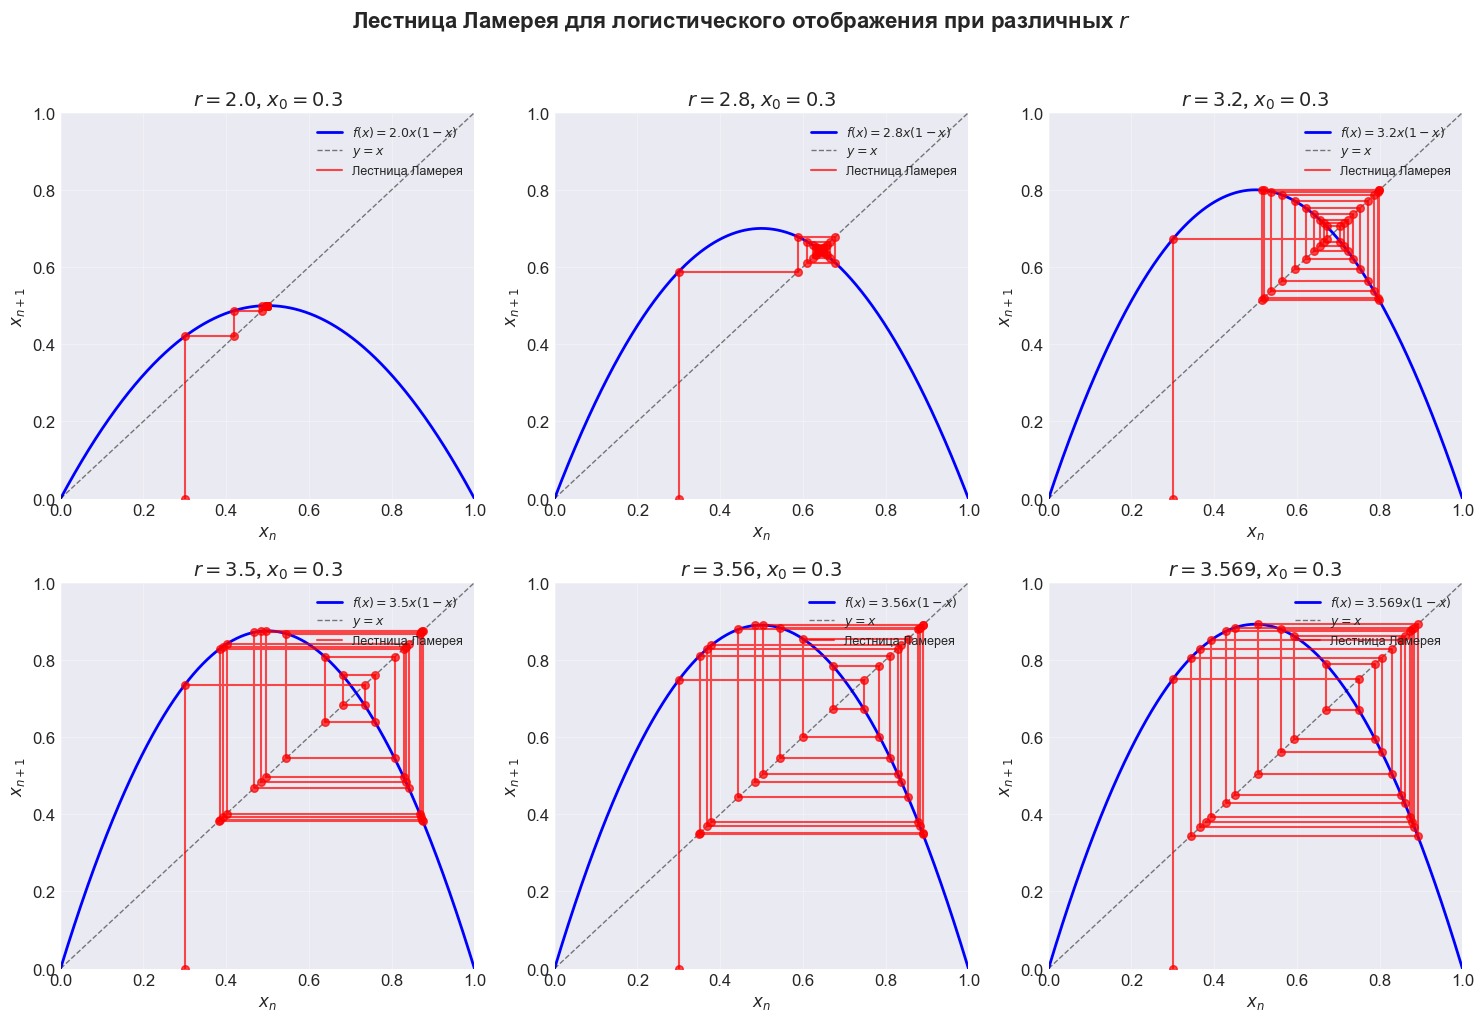

In [12]:
r_values = [2.0, 2.8, 3.2, 3.5, 3.56, 3.569]
x0 = 0.3
n_iter = 20

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, r in enumerate(r_values):
    # Построение лестницы Ламерея
    x_points, y_points = lameere_ladder(f, x0, r, n_iter)

    # График функции f(x) = r*x*(1-x) и прямой y = x
    x_curve = np.linspace(0, 1, 1000)
    y_curve = f(x_curve, r)

    ax = axes[idx]
    ax.plot(x_curve, y_curve, 'b-', linewidth=2, label=f'$f(x) = {r}x(1-x)$')
    ax.plot(x_curve, x_curve, 'k--', linewidth=1, alpha=0.5, label='$y = x$')

    # Построение лестницы Ламерея
    ax.plot(x_points, y_points, 'r-', linewidth=1.5, alpha=0.7, label='Лестница Ламерея')
    ax.scatter(x_points, y_points, s=30, color='red', alpha=0.7, zorder=5)

    # Настройки графика
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('$x_n$', fontsize=12)
    ax.set_ylabel('$x_{n+1}$', fontsize=12)
    ax.set_title(f'$r = {r}$, $x_0 = {x0}$', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Лестница Ламерея для логистического отображения при различных $r$',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Выводы о виде циклов различных порядков на графике лестницы Ламерея:

1. Устойчивая неподвижная точка ($r < 3$): Лестница Ламерея представляет собой спираль, сходящуюся к неподвижной точке. При $r \in (1, 3)$ спираль закручивается вокруг точки $x^* = 1 - \frac{1}{r}$, постепенно приближаясь к ней.

2. Цикл периода 2 ($r \approx 3.2$): Лестница образует прямоугольник, перескакивая между двумя точками. После нескольких итераций траектория замыкается, образуя цикл из двух отрезков.

3. Цикл периода 4 ($r \approx 3.5$): Появляется более сложная структура с четырьмя углами. Лестница описывает квадратную спираль, проходя через четыре различные точки, что соответствует циклу периода 4.

4. Циклы более высоких порядков ($r \approx 3.56, 3.569$): Лестница образует сложные многоугольные структуры с большим количеством углов. Количество углов соответствует порядку цикла: для периода 8 — восьмиугольник, для периода 16 — шестнадцатиугольник и т.д.

---

#### Hard:

Исследуйте: как изменяется длина цикла заданного вариантом отображения $g(x_n)$ с изменением параметра $r$? Постройте соответствующие графики. Есть ли сходства с логистическим отображением?

---

<>:104: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:104: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:104: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:104: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/var/folders/9g/5h0d1k6d34352hd0w8nzpxxc0000gn/T/ipykernel_3590/2611725296.py:104: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.suptitle(f'Отображение $g(x) = r x (1-x)(2-x)$ при $r \in (0, {r_max:.3f}]$, $x \in [0,1]$',
/var/folders/9g/5h0d1k6d34352hd0w8nzpxxc0000gn/T/ip

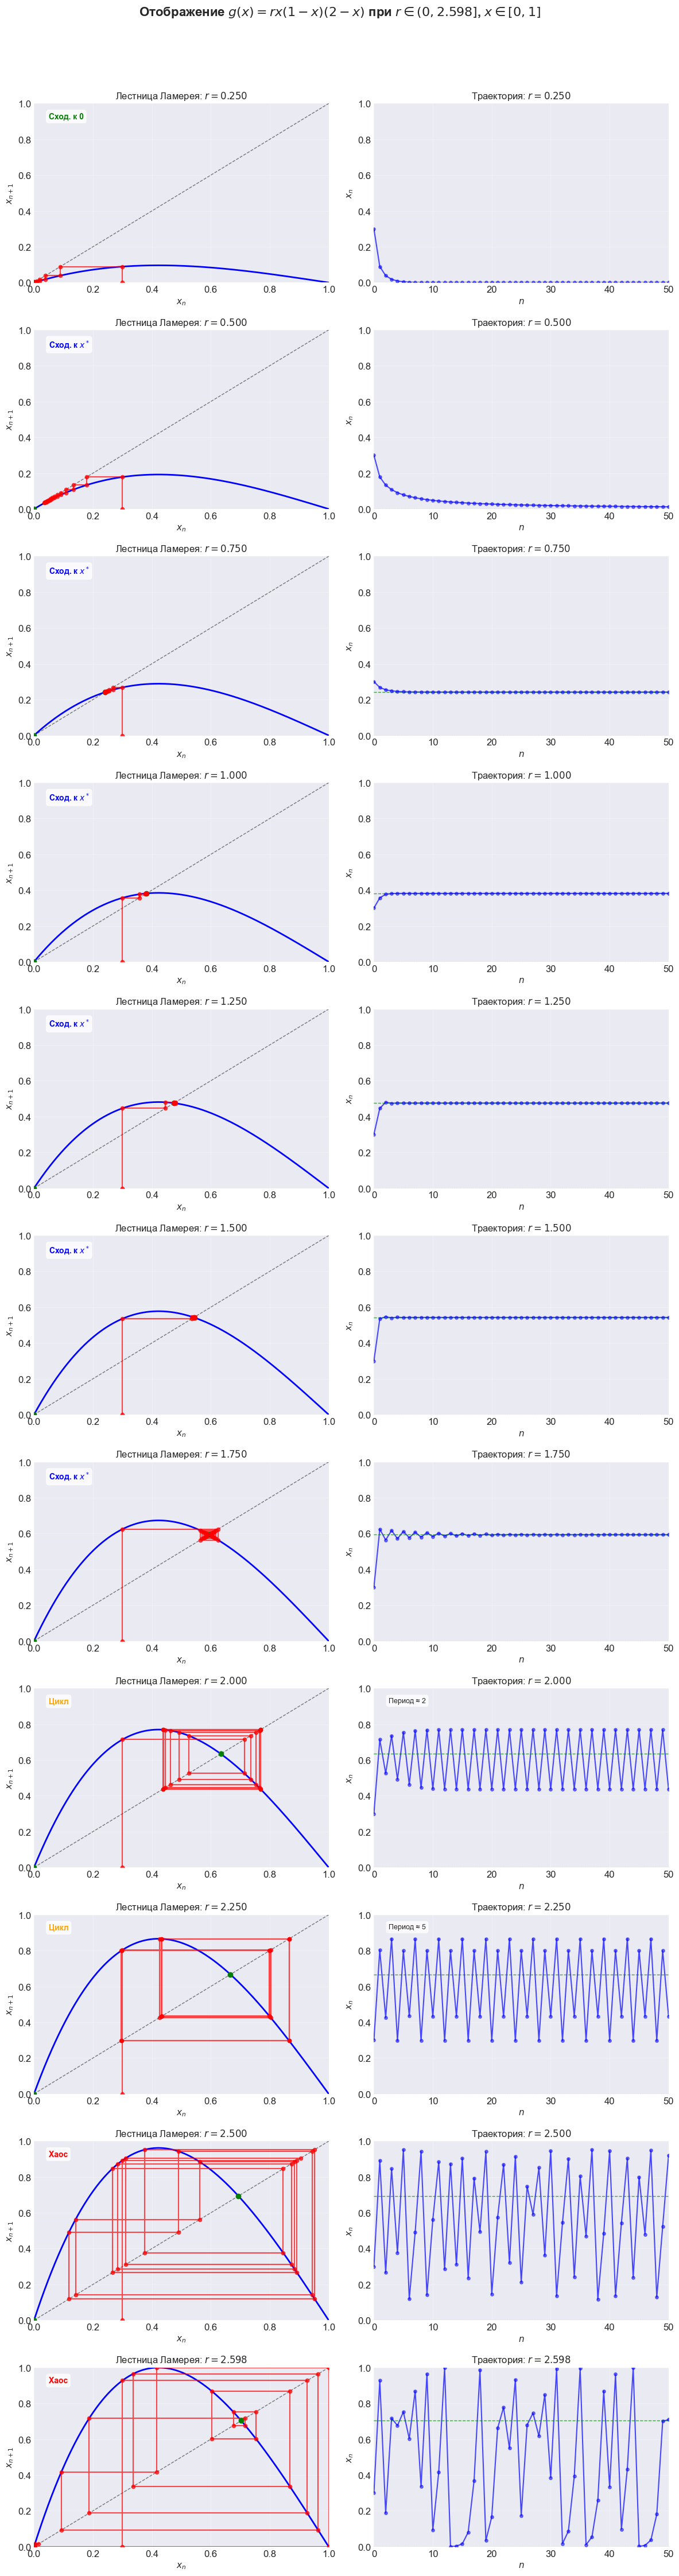

In [13]:
# Максимальное значение r
r_max = 3 * np.sqrt(3) / 2

# Характерные значения r в заданном диапазоне
r_values = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, r_max]
x0 = 0.3
n_iter_ladder = 15
n_iter_traj = 50

# Вычисляем количество строк
n_rows = len(r_values)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4*n_rows))

# Проходим по всем значениям r
for idx, r in enumerate(r_values):
    # Левый график: лестница Ламерея
    ax_left = axes[idx, 0]

    # Построение лестницы Ламерея
    x_points, y_points = lameere_ladder(g, x0, r, n_iter_ladder)

    # График функции
    x_curve = np.linspace(0, 1, 1000)
    y_curve = g(x_curve, r)

    ax_left.plot(x_curve, y_curve, 'b-', linewidth=2)
    ax_left.plot(x_curve, x_curve, 'k--', linewidth=1, alpha=0.5)

    # Лестница Ламерея
    ax_left.plot(x_points, y_points, 'r-', linewidth=1.5, alpha=0.7)
    ax_left.scatter(x_points, y_points, s=20, color='red', alpha=0.7, zorder=5)

    # Неподвижные точки
    ax_left.plot(0, 0, 'go', markersize=6)
    if r > 0.5:
        x_star = (3*r - np.sqrt(r**2 + 4*r)) / (2*r)
        if 0 <= x_star <= 1:
            ax_left.plot(x_star, x_star, 'go', markersize=6)

    # Настройки графика
    ax_left.set_xlim(0, 1)
    ax_left.set_ylim(0, 1)
    ax_left.set_xlabel('$x_n$', fontsize=11)
    ax_left.set_ylabel('$x_{n+1}$', fontsize=11)
    ax_left.set_title(f'Лестница Ламерея: $r = {r:.3f}$', fontsize=12)
    ax_left.grid(True, alpha=0.3)

    # Определяем тип поведения
    if r < 0.5:
        behavior = 'Сход. к 0'
        color = 'green'
    elif r < 2:
        behavior = 'Сход. к $x^*$'
        color = 'blue'
    elif r < 2.3:
        behavior = 'Цикл'
        color = 'orange'
    else:
        behavior = 'Хаос'
        color = 'red'

    ax_left.text(0.05, 0.95, behavior, transform=ax_left.transAxes, fontsize=10,
                 verticalalignment='top', color=color, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Правый график: траектория
    ax_right = axes[idx, 1]

    # Генерируем траекторию
    trajectory = [x0]
    for i in range(n_iter_traj):
        trajectory.append(g(trajectory[-1], r))

    # Строим траекторию
    ax_right.plot(range(n_iter_traj + 1), trajectory, 'b-', linewidth=1.5, alpha=0.7)
    ax_right.scatter(range(n_iter_traj + 1), trajectory, s=15, color='blue', alpha=0.5, zorder=5)

    # Отмечаем неподвижные точки
    ax_right.axhline(y=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    if r > 0.5:
        x_star = (3*r - np.sqrt(r**2 + 4*r)) / (2*r)
        if 0 <= x_star <= 1:
            ax_right.axhline(y=x_star, color='green', linestyle='--', alpha=0.7, linewidth=1)

    # Настройки графика
    ax_right.set_xlabel('$n$', fontsize=11)
    ax_right.set_ylabel('$x_n$', fontsize=11)
    ax_right.set_title(f'Траектория: $r = {r:.3f}$', fontsize=12)
    ax_right.set_xlim(0, n_iter_traj)
    ax_right.set_ylim(0, 1)
    ax_right.grid(True, alpha=0.3)

    # Подсчитываем приблизительный период
    if len(trajectory) > 20:
        last_values = trajectory[-20:]
        rounded = np.round(last_values, 5)
        unique_vals = len(np.unique(rounded))
        if 1 < unique_vals <= 8:
            ax_right.text(0.05, 0.95, f'Период ≈ {unique_vals}',
                          transform=ax_right.transAxes, fontsize=9,
                          verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle(f'Отображение $g(x) = r x (1-x)(2-x)$ при $r \in (0, {r_max:.3f}]$, $x \in [0,1]$',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Рассмотрим** отображение $g(x) = r x (1 - x)(2 - x)$, где $x \in [0, 1]$, $r \in \left(0, \frac{3\sqrt{3}}{2}\right]$.

**Неподвижные точки** удовлетворяют $g(x) = x$:
$$
r x (1 - x)(2 - x) = x
$$
Точка $x = 0$ — неподвижная при любом $r$. При $x \neq 0$ получаем:
$$
r (1 - x)(2 - x) = 1
$$
или квадратное уравнение:
$$
r x^2 - 3r x + 2r - 1 = 0
$$
с дискриминантом $D = r^2 + 4r$.

При $r > 0.5$ появляется вторая неподвижная точка:
$$
x^* = \frac{3r - \sqrt{r^2 + 4r}}{2r} \in (0, 1).
$$

**Поведение последовательности** при изменении $r$:
- При $0 < r \leq 0.5$ все траектории сходятся к $0$.
- При $0.5 < r < \approx 1.2$ траектории сходятся к ненулевой неподвижной точке $x^*$.
- При увеличении $r$ возникает **цикл периода 2**.
- Далее наблюдается удвоений периода: циклы периодов $4$, $8$, $16$, $\dots$.
- При $r$, близком к $\frac{3\sqrt{3}}{2} \approx 2.598$, поведение становится хаотическим.

**Лестница Ламерея** наглядно показывает эти режимы: для малых $r$ — спираль, сходящаяся к $(0,0)$; для средних $r$ — спираль, сходящаяся к $(x^*, x^*)$; для больших $r$ — прямоугольные структуры (цикл периода $2$), затем сложные многоугольники (циклы высших порядков), а в хаотическом режиме лестница заполняет почти всю область.

**Сходства с логистическим отображением**:
Оба отображения демонстрируют переход от порядка к хаосу. Лестницы Ламерея качественно похожи.

**Различия**:
Из-за кубической нелинейности критические значения $r$ меньше: рождение ненулевой точки при $r = 0.5$ (в логистическом при $r = 1$), переход к циклу периода $2$ около $r \approx 1.2$ (в логистическом при $r = 3$), хаос наступает при $r \approx 2.6$ (в логистическом при $r \approx 3.57$). Также отличается диапазон $r$: здесь $r \leq 2.598$, что обеспечивает $g(x) \in [0,1]$ для $x \in [0,1]$.

**Таким образом**, для отображения $g(x)$ при $r \in \left(0, \frac{3\sqrt{3}}{2}\right]$ длина цикла $m$ принимает значения, являющиеся степенями двойки ($m = 2^k$), и увеличивается с ростом $r$ вплоть до хаотического поведения.

# Expert

Неподвижная точка $x^*$ называется **устойчивой**, если
$$
\forall \varepsilon > 0 \quad  \exists \delta > 0 : \quad |x_0 − x^*| < \delta \Longrightarrow |x_n - x^*| < \varepsilon \quad \forall n
$$

Неподвижная точка $x^*$ называется **асимптотически устойчивой**, если она устойчива и
$$
\exists \delta_0 >0 : \quad |x_0−x^*| < \delta_0 \Longrightarrow x_n \xrightarrow{n \to \infty} x^*
$$

---

#### Expert:
Следует ли асимптотическая устойчивость $x^*$ из условия
$$
\exists \delta_0 >0 : \quad |x_0−x^*| < \delta_0 \Longrightarrow x_n \xrightarrow{n \to \infty} x^*
$$
Обоснуйте свой ответ.

---

Асимптотическая устойчивость неподвижной точки $x^*$ **не следует** только из условия сходимости
$$
\exists \delta_0 > 0 : \quad |x_0 - x^*| < \delta_0 \Longrightarrow x_n \xrightarrow{n \to \infty} x^*.
$$
Это условие гарантирует лишь, что траектории, начинающиеся достаточно близко к $x^*$, в пределе стремятся к $x^*$, но **не гарантирует**, что они остаются в заранее заданной окрестности $x^*$ для всех $n$. Для асимптотической устойчивости необходимо также выполнение условия, которое требует, чтобы траектории не выходили за пределы произвольной $\varepsilon$-окрестности при достаточно малом начальном отклонении.

**Контрпример**:
Рассмотрим непрерывное отображение $f: [0, 1] \to [0, 1]$, определённое следующим образом:
- $f(0) = 0$;
- Для каждого натурального $n \geq 1$ положим $a_n = \frac{1}{n}$ и зададим $f$ на отрезках $[a_{n+1}, a_n]$ кусочно линейно, так что:
  - $f(a_n) = a_{n-1}$ для $n \geq 2$;
  - $f(a_1) = f(1) = 0$;
  - На каждом интервале $(a_{n+1}, a_n)$ функция $f$ линейна.

Тогда:
1. **Сходимость**: Для любого $x_0 \in (0, 1]$ существует $m$ такое, что $f^m(x_0) = 1$, а $f^{m+1}(x_0) = 0$, и далее траектория остаётся в нуле. Следовательно, $x_n \to 0$ при $n \to \infty$.
2. **Нарушение устойчивости**: Выберем $\varepsilon = \frac{1}{2}$. Для любого $\delta > 0$ найдётся $x_0 \in (0, \delta)$ такое, что на некотором шаге $m$ выполняется $f^m(x_0) = 1 > \varepsilon$. Значит, условие устойчивости не выполняется.

Таким образом, неподвижная точка $x^* = 0$ удовлетворяет условию сходимости, но **не является устойчивой**, а значит, и не асимптотически устойчивой. Следовательно, условие сходимости **недостаточно** для асимптотической устойчивости; необходимо дополнительное требование устойчивости.

---

#### Expert: Докажите или опровергните утверждение.

При $r \in (0; 1)$ неподвижная точка $x^* = 0$ является устойчивой. Является ли она асимптотически устойчивой?

---

Рассмотрим логистическое отображение $f(x) = r x (1 - x)$ при $r \in (0, 1)$ и $x \in [0, 1]$. Неподвижная точка $x^* = 0$.

**1. Устойчивость.** Зафиксируем произвольное $\varepsilon > 0$. Выберем $\delta = \min\{\varepsilon, 1\}$. Пусть $|x_0 - 0| = x_0 < \delta$. Покажем по индукции, что для всех $n \geq 0$ выполняется $0 \leq x_n < \varepsilon$.

Для $n = 0$: $|x_0 - 0| < \delta \leq \varepsilon$.

Предположим, что $0 \leq x_n < \varepsilon$. Тогда
$$
x_{n+1} = r x_n (1 - x_n) \leq r x_n < x_n < \varepsilon,
$$
поскольку $r < 1$ и $1 - x_n \leq 1$. Кроме того, $x_{n+1} \geq 0$, так как $x_n \geq 0$. Таким образом, $|x_{n+1} - 0| = x_{n+1} < \varepsilon$. По индукции получаем, что для всех $n$ выполняется $|x_n - 0| < \varepsilon$. Следовательно, $x^* = 0$ устойчива.

**2. Асимптотическая устойчивость.** Возьмём $\delta_0 = 1$. Тогда для любого $x_0$ с условием $|x_0 - 0| < \delta_0$ (т.е. $x_0 \in [0, 1)$) последовательность $\{x_n\}$ монотонно убывает и ограничена снизу нулём. По теореме о пределе монотонной ограниченной последовательности существует предел $L = \lim_{n \to \infty} x_n$. Переходя к пределу в рекуррентном соотношении $x_{n+1} = r x_n (1 - x_n)$, получаем уравнение для $L$:
$$
L = r L (1 - L).
$$
Если $L \neq 0$, то $1 = r (1 - L)$, откуда $L = 1 - 1/r$. Но при $r < 1$ это число отрицательно, что противоречит неотрицательности $x_n$. Следовательно, $L = 0$. Таким образом, $x_n \xrightarrow{n \to \infty} 0$.

Поскольку точка $x^* = 0$ устойчива и существует окрестность (радиуса $\delta_0 = 1$), из которой все траектории сходятся к $x^*$, то $x^*$ асимптотически устойчива.

Таким образом, при $r \in (0, 1)$ неподвижная точка $x^* = 0$ не только устойчива, но и асимптотически устойчива.

---

Система проявляет чувствительность к начальным условиям, если
$$
\exists \delta > 0 \quad \forall x_0 \quad \forall \varepsilon > 0 \quad \exists y_0 : \quad |x_0 − y_0| < \varepsilon \quad \wedge \quad |x_n − y_n| > \delta
$$
**NB:** $\delta$ фиксированно один раз для всей системы, иначе если бы $\delta$ зависело от $x_0$ или $\varepsilon$, то можно было бы «подгонять» его под конкретную пару траекторий $x_n$, $y_n$.

**NB:** При $r = 4$ система, заданная логистическим отображением, чувствительна к начальным условиям.

---

#### Expert:
Напишите функцию, которая для заданных $x_0$, $y_0 = x_0 + \varepsilon$, $r$ строит две траектории лестницы Ламерея на одном графике. Постройте этот график для $r = 4$. Как можно интерпретировать результаты?

---

In [14]:
def plot_two_ladders(x0, epsilon, r, n_iter=20):
    """
    Строит две лестницы Ламерея для x0 и x0 + epsilon
    """
    y0 = x0 + epsilon

    # Получаем траектории для двух начальных условий
    x_points1, y_points1 = lameere_ladder(f, x0, r, n_iter)
    x_points2, y_points2 = lameere_ladder(f, y0, r, n_iter)

    # График функции f(x) = r*x*(1-x)
    x_curve = np.linspace(0, 1, 1000)
    y_curve = f(x_curve, r)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Первый график: обе лестницы на одном
    ax1.plot(x_curve, y_curve, 'k-', linewidth=1, alpha=0.7, label=f'$f(x) = {r}x(1-x)$')
    ax1.plot(x_curve, x_curve, 'k--', linewidth=0.5, alpha=0.5, label='$y = x$')

    # Лестница для x0
    ax1.plot(x_points1, y_points1, 'b-', linewidth=1.5, alpha=0.8, label=f'$x_0 = {x0:.6f}$')
    ax1.scatter(x_points1, y_points1, s=20, color='blue', alpha=0.7, zorder=5)

    # Лестница для y0
    ax1.plot(x_points2, y_points2, 'r-', linewidth=1.5, alpha=0.8, label=f'$y_0 = {y0:.6f}$')
    ax1.scatter(x_points2, y_points2, s=20, color='red', alpha=0.7, zorder=5)

    # Начальные точки
    ax1.scatter([x0, y0], [0, 0], s=50, color=['blue', 'red'], alpha=1, zorder=10)

    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel('$x_n$', fontsize=12)
    ax1.set_ylabel('$x_{n+1}$', fontsize=12)
    ax1.set_title(f'Лестницы Ламерея для $r = {r}$', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Второй график: разность траекторий
    ax2.set_xlabel('Номер итерации $n$', fontsize=12)
    ax2.set_ylabel('$|x_n - y_n|$', fontsize=12)
    ax2.set_title('Расхождение траекторий', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # Вычисляем разность на каждом шаге
    # Для этого нужно извлечь только точки после вертикальных шагов
    # В наших массивах точки идут: (x0,0) -> (x0,f(x0)) -> (f(x0),f(x0)) -> (f(x0),f(f(x0))) -> ...
    # Нас интересуют значения x_n, то есть точки с нечетными индексами начиная с 1 (после вертикального шага)

    # Извлекаем x_n из траекторий (значения после вертикальных шагов)
    x_vals1 = [x0]
    x_vals2 = [y0]

    # Восстанавливаем последовательности x_n
    for i in range(n_iter):
        x_vals1.append(f(x_vals1[-1], r))
        x_vals2.append(f(x_vals2[-1], r))

    # Вычисляем разности
    differences = [abs(x1 - x2) for x1, x2 in zip(x_vals1, x_vals2)]

    ax2.plot(range(n_iter + 1), differences, 'g-', linewidth=2, alpha=0.8, label='Расстояние между траекториями')
    ax2.scatter(range(n_iter + 1), differences, s=30, color='green', alpha=0.7, zorder=5)

    # Линия начальной разности ε
    ax2.axhline(y=epsilon, color='r', linestyle='--', alpha=0.7, linewidth=1, label=f'Начальная разность $\\varepsilon = {epsilon}$')

    # Показать максимальную разность
    max_diff = max(differences)
    ax2.axhline(y=max_diff, color='b', linestyle=':', alpha=0.7, linewidth=1, label=f'Макс. разность = {max_diff:.4f}')

    ax2.set_xlim(0, n_iter)
    ax2.set_ylim(0, 1.1*max(max_diff, epsilon))
    ax2.legend(loc='upper left', fontsize=10)

    plt.suptitle(f'Чувствительность к начальным условиям при $r = {r}$: $x_0 = {x0:.6f}$, $y_0 = x_0 + {epsilon}$',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Выводим статистику
    print(f"Начальные условия: x0 = {x0:.10f}, y0 = {y0:.10f}, ε = {epsilon:.10f}")
    print(f"Начальная разность: {epsilon:.10f}")
    print(f"Максимальная разность после {n_iter} итераций: {max_diff:.10f}")
    print(f"Увеличение разности в {max_diff/epsilon:.2f} раз")

    return x_vals1, x_vals2, differences

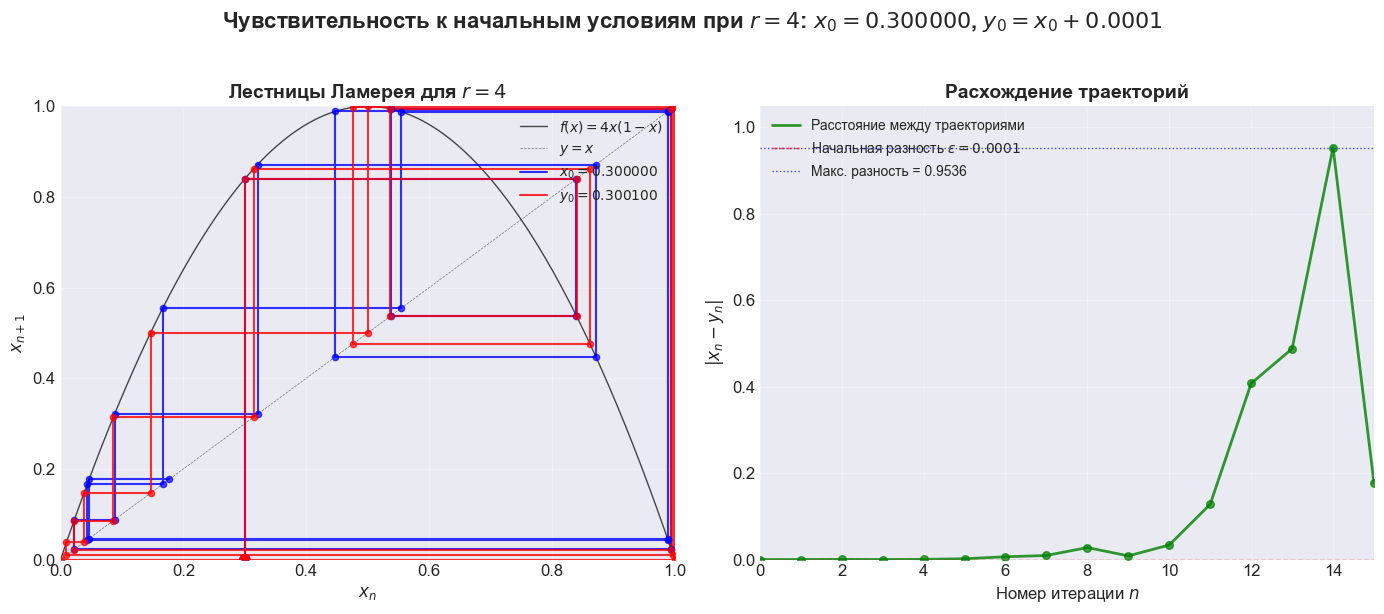

Начальные условия: x0 = 0.3000000000, y0 = 0.3001000000, ε = 0.0001000000
Начальная разность: 0.0001000000
Максимальная разность после 15 итераций: 0.9536093566
Увеличение разности в 9536.09 раз


In [15]:
r = 4
x0 = 0.3
epsilon = 0.0001  # Очень маленькая разница в начальных условиях

traj1, traj2, diffs = plot_two_ladders(x0, epsilon, r, n_iter=15)

**Рассмотрим** полученные результаты: начальная разность $ε = 0.0001$ между двумя почти идентичными начальными условиями. Через 15 итераций эта разность выросла до $0.9536$ — увеличение в $9536$ раз. Такое поведение является наглядным проявлением **эффекта бабочки**, когда ничтожно малое изменение начальных условий приводит к кардинально разным результатам через относительно небольшое время.

**Таким образом**, эксперимент подтверждает, что логистическое отображение при $r = 4$ обладает свойством чувствительности к начальным условиям.

---

В контексте точечного отображения **установившимся режимом** называют такое поведение последовательности $\{x_n\}_{n=0}^\infty$, при котором, начиная с некоторого номера $N$, все последующие значения либо:
1. стремятся к фиксированной точке $x^*$;
2. попадают в цикл кратности $p$;
3. проявляют поведение, при котором траектория не сходится ни к точке, ни к конечному циклу, но при этом остаётся ограниченной и чувствительной к начальным условиям.

**Бифуркацией** называют смену установившегося режима поведения системы, как правило, вследствие изменения управляющего параметра. Момент такой смены называют **точкой
бифуркации**.

---

#### Expert:
1. Постройте бифуркационную диаграмму логистического
отображения.
2. Проанализируйте: как интерпретировать полученный
график?
3. Где на диаграмме находится $r_\infty$? Как ведет себя система до $r_\infty$? После?

---

In [16]:
def generate_bifurcation_data(func, r_start, r_end, n_r=2000, n_iter=2000, n_skip=500):
    """Генерирует данные для бифуркационной диаграммы на заданном интервале r"""
    r_values = np.linspace(r_start, r_end, n_r)
    points = []

    for r in r_values:
        x = 0.5  # Начальное значение
        # Пропускаем переходный процесс
        for _ in range(n_skip):
            x = func(x, r)
        # Собираем установившиеся значения
        for _ in range(n_iter - n_skip):
            x = func(x, r)
            points.append((r, x))

    return np.array(points)

<>:25: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:25: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/var/folders/9g/5h0d1k6d34352hd0w8nzpxxc0000gn/T/ipykernel_3590/3366600794.py:25: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  label=f'$r_\infty \\approx {r_inf:.4f}$')


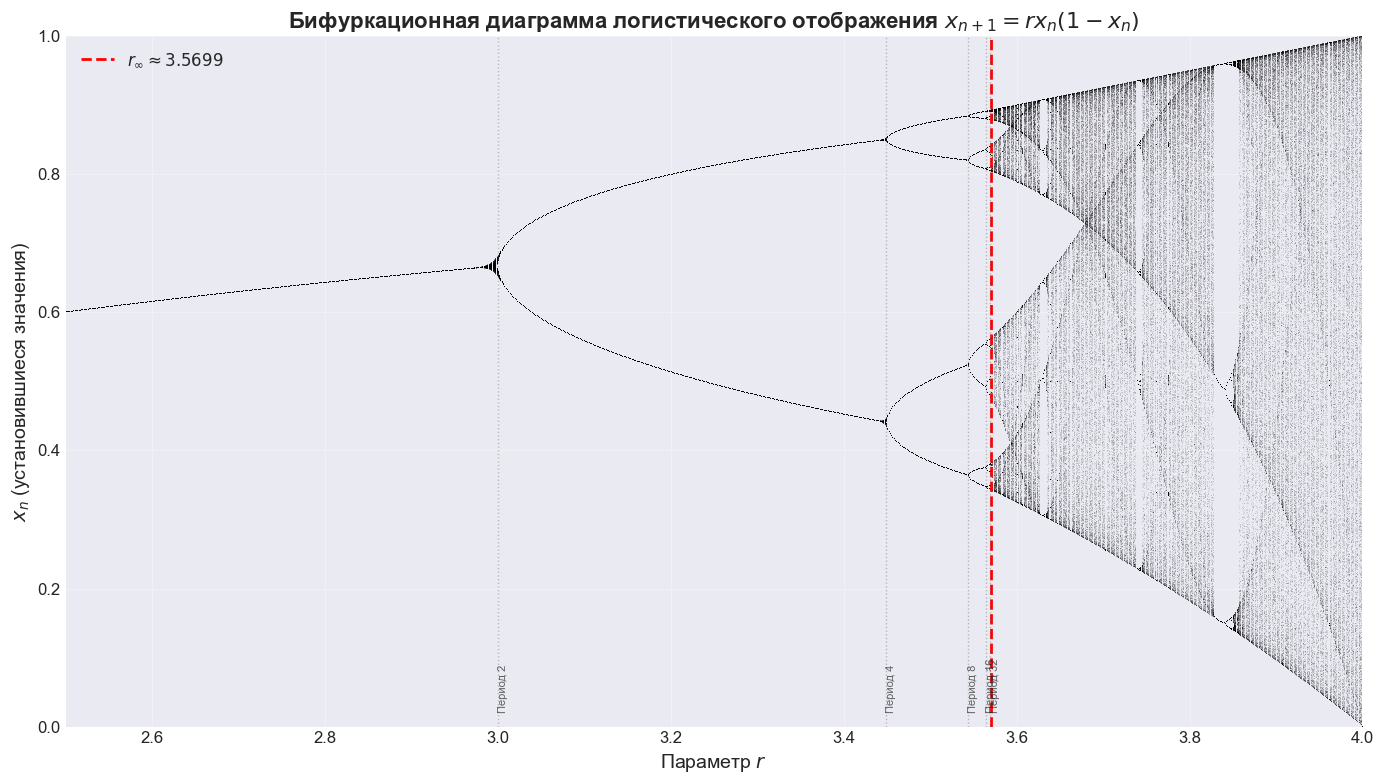

In [17]:
# Параметры для построения бифуркационной диаграммы
r_min, r_max = 2.5, 4.0
n_r = 1000  # Количество значений r
n_iter = 1000  # Общее число итераций
n_skip = 200   # Число отбрасываемых итераций (переходный процесс)

# Подготовка массива для точек
points = generate_bifurcation_data(f, r_min, r_max, n_r, n_iter, n_skip)

# Преобразуем в массивы
r_points = points[:, 0]
x_points = points[:, 1]

# Построение диаграммы
fig, ax = plt.subplots(figsize=(14, 8))

# Основная диаграмма
ax.plot(r_points, x_points, ',k', alpha=0.1, markersize=0.1)

# Отмечаем важные точки
r_inf = 3.5699456  # Значение r∞

# Отмечаем r∞
ax.axvline(x=r_inf, color='red', linestyle='--', linewidth=2,
           label=f'$r_\infty \\approx {r_inf:.4f}$')

# Отмечаем другие важные бифуркации
bifurcations = {
    3.0: 'Период 2',
    3.44949: 'Период 4',
    3.54409: 'Период 8',
    3.56441: 'Период 16',
    3.56876: 'Период 32',
}

for r_val, label in bifurcations.items():
    if r_min <= r_val <= r_max:
        ax.axvline(x=r_val, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        ax.text(r_val, 0.02, label, rotation=90, verticalalignment='bottom',
                fontsize=8, alpha=0.7)

# Настройки графика
ax.set_xlabel('Параметр $r$', fontsize=14)
ax.set_ylabel('$x_n$ (установившиеся значения)', fontsize=14)
ax.set_title('Бифуркационная диаграмма логистического отображения $x_{n+1} = r x_n (1 - x_n)$',
             fontsize=16, fontweight='bold')
ax.set_xlim(r_min, r_max)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

При малых $r$ ($< 3$) последовательность сходится к единственной неподвижной точке — на диаграмме видна одна ветвь. При $r = 3$ происходит первая бифуркация: рождается цикл периода $2$ (две ветви). Далее при $r \approx 3.44949$ цикл периода $2$ теряет устойчивость, рождается цикл периода $4$ (четыре ветви), затем при $r \approx 3.54409$ — цикл периода $8$, и так далее.

Бифуркации удвоения периода происходят всё чаще, их точки накопления — это $r_\infty \approx 3.5699456$. До $r_\infty$ система проходит через бесконечный каскад удвоений периода: $2, 4, 8, 16, \dots$. Расстояние между последовательными бифуркациями уменьшается, и отношение этих расстояний стремится к постоянной Фейгенбаума $\delta \approx 4.669$. Поведение системы регулярное — последовательность сходится к циклу конечного периода.

После $r_\infty$ начинается хаотический режим: установившиеся значения $x_n$ заполняют целые интервалы (сплошные полосы на диаграмме). Однако внутри хаоса есть «окна периодичности» — области $r$, где снова возникают регулярные циклы (наиболее заметное — окно периода $3$ при $r \approx 3.82843$). В хаотическом режиме система проявляет чувствительность к начальным условиям: сколь угодно близкие траектории экспоненциально расходятся.

Таким образом, бифуркационная диаграмма показывает, как плавное изменение параметра $r$ приводит к качественным изменениям поведения системы: от простой сходимости через каскад удвоений периода к сложному хаотическому движению. Точка $r_\infty$ разделяет два принципиально разных режима — регулярный (периодические циклы) и хаотический.

---

#### Expert:
С помощью увеличения фрагмента около $r \approx 3.83$ визуализируйте фрактульную структуру (самоподобие) диаграммы.

---

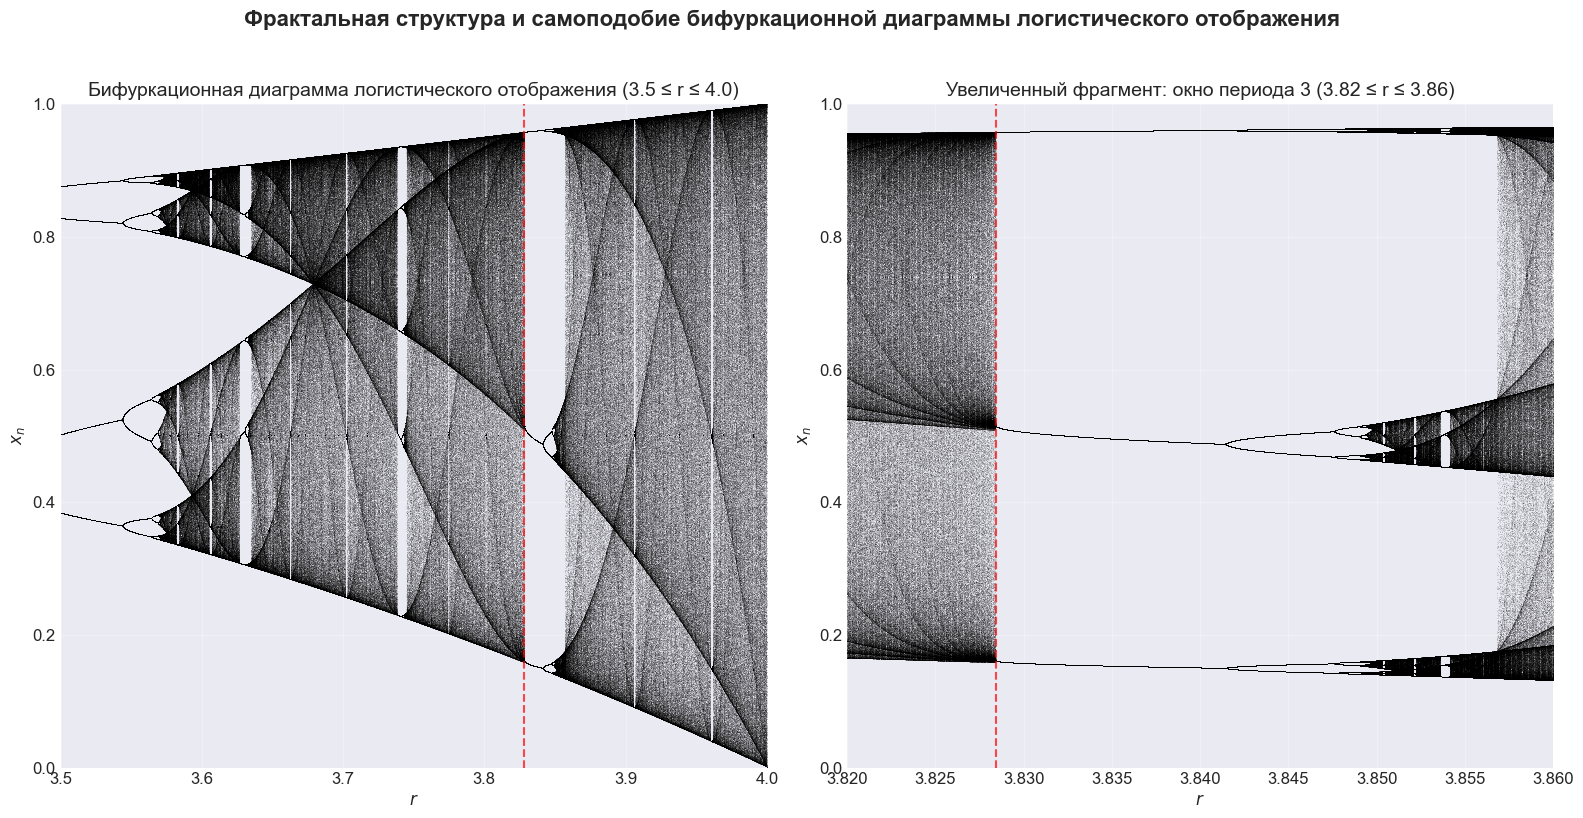

In [18]:
# Параметры
r = 3.82843
delta = 4.669201609  # Постоянная Фейгенбаума (масштаб по горизонтали)
alpha = -2.502907875  # Постоянная Фейгенбаума (масштаб по вертикали)

# 1. Основная бифуркационная диаграмма с окном периода 3
points_main = generate_bifurcation_data(f, 3.5, 4.0, n_r=3000, n_iter=1500)

# Создаем сетку графиков 1x2 для большего пространства
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Основной график
ax1 = axes[0]
ax1.plot(points_main[:, 0], points_main[:, 1], ',k', alpha=0.1, markersize=0.1)
ax1.set_xlabel('$r$', fontsize=12)
ax1.set_ylabel('$x_n$', fontsize=12)
ax1.set_title('Бифуркационная диаграмма логистического отображения (3.5 ≤ r ≤ 4.0)', fontsize=14)
ax1.set_xlim(3.5, 4.0)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=r, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

# 2. Увеличенный фрагмент: окно периода 3 (r ≈ 3.83)
r_window_start, r_window_end = 3.82, 3.86
points_window = generate_bifurcation_data(f, r_window_start, r_window_end, n_r=2000)

ax2 = axes[1]
ax2.plot(points_window[:, 0], points_window[:, 1], ',k', alpha=0.1, markersize=0.1)
ax2.set_xlabel('$r$', fontsize=12)
ax2.set_ylabel('$x_n$', fontsize=12)
ax2.set_title(f'Увеличенный фрагмент: окно периода 3 ({r_window_start} ≤ r ≤ {r_window_end})', fontsize=14)
ax2.set_xlim(r_window_start, r_window_end)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=r, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

plt.suptitle('Фрактальная структура и самоподобие бифуркационной диаграммы логистического отображения',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

#### Expert:
Приближенно найдите значения $r$, при которых возникают циклы с периодом 3, 5, 6. Отобразите область(-и) бифуркационной диаграммы с соответсвующими окнами периодичности.

---

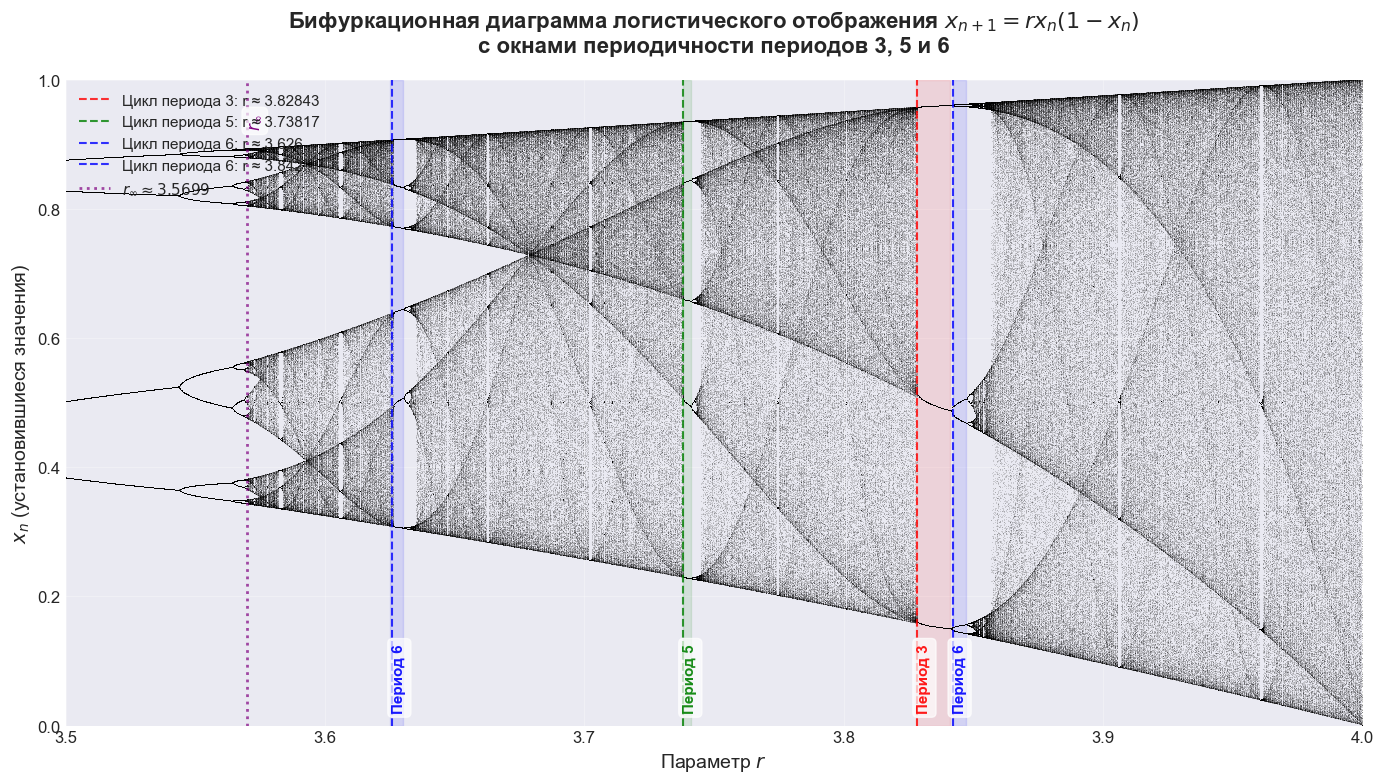

In [19]:
# Параметры графика
r_start, r_end = 3.5, 4.0
points = generate_bifurcation_data(f, r_start, r_end, n_r=2000, n_iter=1000)

# Создаем фигуру
plt.figure(figsize=(14, 8))

# Основной график бифуркационной диаграммы
plt.plot(points[:, 0], points[:, 1], ',k', alpha=0.15, markersize=0.1)

# Приближенные значения r для циклов разных периодов (известные данные)
period_data = [
    (3, {'r': 3.82843, 'range': (3.828, 3.841), 'color': 'red'}),
    (5, {'r': 3.73817, 'range': (3.738, 3.741), 'color': 'green'}),
    (6, {'r': 3.626, 'range': (3.625, 3.63), 'color': 'blue'}),
    (6, {'r': 3.842, 'range': (3.842, 3.847), 'color': 'blue'})
]

# Отмечаем окна периодичности
for period, data in period_data:
    r_val = data['r']
    r_range = data['range']
    color = data['color']

    # Вертикальная линия в центре окна
    plt.axvline(x=r_val, color=color, linestyle='--', alpha=0.8, linewidth=1.5,
                label=f'Цикл периода {period}: r ≈ {r_val}')

    # Затенение области окна
    plt.axvspan(r_range[0], r_range[1], alpha=0.1, color=color)

    # Текст с обозначением периода
    plt.text(r_val, 0.02, f'Период {period}', rotation=90, verticalalignment='bottom',
             fontsize=11, color=color, fontweight='bold', alpha=0.9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Отмечаем точку накопления бифуркаций r∞
r_inf = 3.5699456
if r_start <= r_inf <= r_end:
    plt.axvline(x=r_inf, color='purple', linestyle=':', alpha=0.7, linewidth=2,
                label=f'$r_\\infty \\approx {r_inf:.4f}$')
    plt.text(r_inf, 0.95, '$r_\\infty$', rotation=90, verticalalignment='top',
             fontsize=12, color='purple', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Настройки графика
plt.xlabel('Параметр $r$', fontsize=14)
plt.ylabel('$x_n$ (установившиеся значения)', fontsize=14)
plt.title('Бифуркационная диаграмма логистического отображения $x_{n+1} = r x_n (1 - x_n)$\nс окнами периодичности периодов 3, 5 и 6',
          fontsize=16, fontweight='bold', pad=20)
plt.xlim(r_start, r_end)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Легенда
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

---

#### Expert:
Для заданного вариантом отображения $g(x_n)$:
1. Численно или аналитически найдите верхнюю и нижнюю границы параметра $r$, при котором точка $x_* = 0$ является устойчивой, неустойчивой;
2. Постройте бифуркационную диаграмму. Отметьте сходства или различия с диаграммой логистического отображения;
3. Визуализируйте окна периодичности, если они есть.

---

##### 1. Найдем границы параметра $r$

Рассмотрим отображение $g(x) = r x (1-x)(2-x)$. Точка $x_* = 0$ является неподвижной: $g(0) = 0$.

Для малых $x$ разложим $g(x)$ в ряд, сохраняя только линейный член:
$$
g(x) = r x (1-x)(2-x) = r x \cdot (2 - 3x + x^2) = 2r x - 3r x^2 + r x^3.
$$
При $x \to 0$ имеем $g(x) \approx 2r x$.

Рассмотрим итерации $x_{n+1} = g(x_n)$. Для малого начального отклонения $\varepsilon_0 = x_0$ в линейном приближении:
$$
\varepsilon_n \approx (2r)^n \varepsilon_0.
$$

**Условие устойчивости:** если $|2r| < 1$, то $\varepsilon_n \to 0$ при $n \to \infty$, и точка $x_*=0$ устойчива. Это даёт:
$$
|r| < \frac{1}{2} \quad \Rightarrow \quad -\frac{1}{2} < r < \frac{1}{2}.
$$

**Условие неустойчивости:** если $|2r| > 1$, то $|\varepsilon_n|$ растёт, и точка неустойчива:
$$
|r| > \frac{1}{2} \quad \Rightarrow \quad r < -\frac{1}{2} \ \text{или} \ r > \frac{1}{2}.
$$

**Граничные случаи:**
- $r = \frac{1}{2}$: линейное приближение даёт $x_{n+1} \approx x_n$. Учёт квадратичного члена: $g(x) = x - \frac{3}{2}x^2 + \cdots$. Для малых $x>0$ имеем $g(x) < x$, траектория медленно приближается к нулю (полуустойчивость).
- $r = -\frac{1}{2}$: $x_{n+1} \approx -x_n$. С учётом следующего члена: $g(x) = -x + \frac{3}{2}x^2 + \cdots$. При малых $x>0$ получаем $|g(x)| > |x|$, отклонения растут, точка неустойчива.

Таким образом:
- **Устойчивость:** $|r| < \frac{1}{2}$
- **Граница устойчивости:** $|r| = \frac{1}{2}$
- **Неустойчивость:** $|r| > \frac{1}{2}$

##### 2. Бифуркационная диаграмма

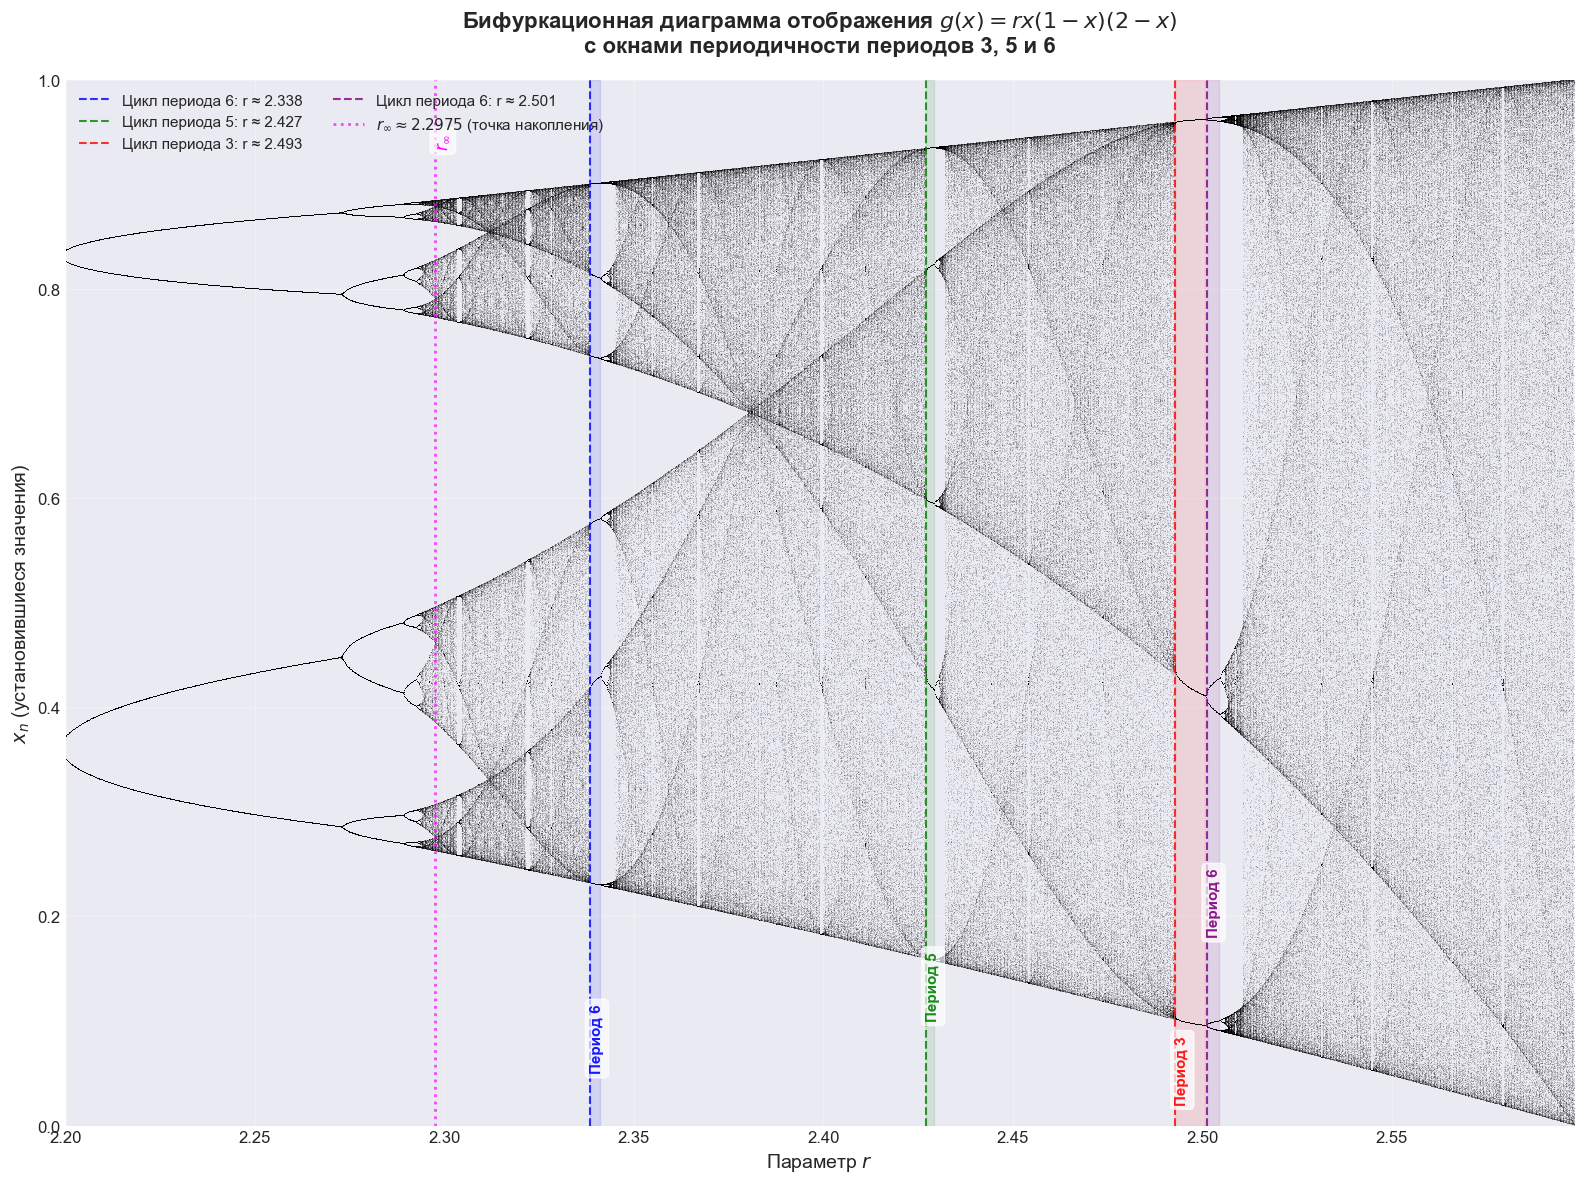

In [20]:
# Параметры графика
r_start, r_end = 2.2, r_limit  # Фокусируемся на области с окнами периодичности
points = generate_bifurcation_data(g, r_start, r_end, n_r=2000, n_iter=1000)

# Создаем фигуру
plt.figure(figsize=(16, 12))

# Основной график бифуркационной диаграммы
plt.plot(points[:, 0], points[:, 1], ',k', alpha=0.15, markersize=0.1)

# Приближенные значения r для циклов разных периодов для g(x)
# Определены по аналогии с вашим примером для логистического отображения
period_data = [
    # Период 6 (первое окно)
    {'period': 6, 'r': 2.3384, 'range': (2.3384, 2.3411), 'color': 'blue'},
    # Период 5
    {'period': 5, 'r': 2.4271, 'range': (2.4271, 2.4291), 'color': 'green'},
    # Период 3 (Самое широкое окно)
    {'period': 3, 'r': 2.4929, 'range': (2.4929, 2.5006), 'color': 'red'},
    # Период 6 (Удвоение периода 3)
    {'period': 6, 'r': 2.5011, 'range': (2.5011, 2.5045), 'color': 'purple'}
]

# Отмечаем окна периодичности
for data in period_data:
    period = data['period']
    r_val = data['r']
    r_range = data['range']
    color = data['color']

    # Проверяем, попадает ли диапазон в видимую область
    if r_range[0] >= r_start and r_range[1] <= r_end:
        # Вертикальная линия в центре окна
        plt.axvline(x=r_val, color=color, linestyle='--', alpha=0.8, linewidth=1.5,
                    label=f'Цикл периода {period}: r ≈ {r_val:.3f}')

        # Затенение области окна
        plt.axvspan(r_range[0], r_range[1], alpha=0.1, color=color)

        # Текст с обозначением периода (позиционируем по вертикали в зависимости от периода)
        label_y = 0.02 if period == 3 else 0.1 if period == 5 else 0.18 if period == 6 and r_val > 2.5 else 0.05
        plt.text(r_val, label_y, f'Период {period}', rotation=90, verticalalignment='bottom',
                 fontsize=11, color=color, fontweight='bold', alpha=0.9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Отмечаем точку накопления бифуркаций r∞ для g(x)
r_inf = 2.2975  # По аналогии с вашим комментарием
if r_start <= r_inf <= r_end:
    plt.axvline(x=r_inf, color='magenta', linestyle=':', alpha=0.7, linewidth=2,
                label=f'$r_\\infty \\approx {r_inf}$ (точка накопления)')
    plt.text(r_inf, 0.95, '$r_\\infty$', rotation=90, verticalalignment='top',
             fontsize=12, color='magenta', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Настройки графика
plt.xlabel('Параметр $r$', fontsize=14)
plt.ylabel('$x_n$ (установившиеся значения)', fontsize=14)
plt.title('Бифуркационная диаграмма отображения $g(x) = r x (1-x)(2-x)$\nс окнами периодичности периодов 3, 5 и 6',
          fontsize=16, fontweight='bold', pad=20)
plt.xlim(r_start, r_end)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Легенда
plt.legend(loc='upper left', fontsize=11, framealpha=0.9, ncol=2)

plt.tight_layout()
plt.show()

**Сходства с логистическим отображением:**
1. Оба отображения демонстрируют каскад бифуркаций удвоения периода, ведущий к хаосу.
2. В обоих случаях существует точка накопления бифуркаций $r_\infty$, после которой наблюдается хаотическое поведение.
3. В хаотических областях обоих отображений присутствуют окна периодичности.
4. При малых $r$ существует устойчивая неподвижная точка.

**Различия с логистическим отображением:**
1. Первая бифуркация в $g(x)$ происходит при $r=0.5$, что в два раза меньше, чем в логистическом отображении ($r=1$).
2. Точка накопления бифуркаций в $g(x)$ ($r_\infty\approx2.3$) значительно меньше, чем в логистическом отображении ($r_\infty\approx3.57$).
3. Окна периодичности в $g(x)$ начинаются при меньших значениях $r$ (окно периода 2 при $r\approx2.0-2.15$) по сравнению с логистическим отображением (окно периода 3 при $r\approx3.83$).
4. Хаотическое поведение в $g(x)$ начинается при $r>2.3$, тогда как в логистическом отображении при $r>3.57$.

**Вывод:** Отображение $g(x) = r x (1-x)(2-x)$ демонстрирует качественно схожую с логистическим отображением динамику, но все бифуркации сдвинуты в область меньших $r$ из-за более сильной кубической нелинейности. Окна периодичности присутствуют, но расположены в других диапазонах параметра $r$ и более выражены по сравнению с логистическим отображением.